# CLIMADA Hazard Integration Workflow

**Purpose**: Convert gridded return periods (from Notebook 01) into CLIMADA Hazard flood depth maps using JRC flood data and CLIMADA-Petals.

**Prerequisites**:
- ✅ Completed Notebook 01 (especially Section 13.5: return period grids)
- ✅ Have `return-period.nc` files from Section 13.5
- ✅ CLIMADA and CLIMADA-petals installed

**What this notebook does**:
1. Loads gridded return periods from Notebook 01
2. Downloads JRC flood depth maps (8 return period layers)
3. Applies CLIMADA Petals regrid + flood_depth operations
4. Creates CLIMADA event-based Hazard objects (8 events, one per return period)
5. Saves hazard for use in impact calculations (Notebook 03)

**What this notebook does NOT do**:
- ❌ Re-run calibration (use Notebook 01)
- ❌ Re-calculate return periods (use Notebook 01)
- ❌ Calculate impacts (that's Notebook 03)

---

**Workflow**:
```
Notebook 01 (Calibration)        Notebook 02 (Hazard + Depth)    Notebook 03 (Impact)
├─ Generate return period grid    ├─ Load return period grid  →   ├─ Load hazard
├─ Save return-period.nc          ├─ Download JRC maps            ├─ Define exposure
└─ Done                           ├─ Petals regrid + flood_depth  ├─ Calculate impacts
                                  ├─ Create 8 event Hazard        └─ Trigger decisions
                                  └─ Save climada_hazard.hdf5
```

## Overview: From Return Periods to Flood Depth

**Input**: Gridded return period (lat/lon grid with values in **years**)
- Source: Notebook 01, Section 13.5
- Format: `return-period.nc` with dims (latitude, longitude)

**Process**: 
- Download JRC flood depth maps (8 return periods: 1, 10, 20, 50, 75, 100, 200, 500 years)
- Regrid return period grid to match JRC resolution (bilinear interpolation)
- Interpolate flood depth between JRC layers based on return period values
- Apply optional FLOPROS protection masking

**Output**: CLIMADA Hazard object
- 8 synthetic events (one per JRC return period)
- Intensity = flood depth (meters)
- Saved as HDF5 for Notebook 03

## 0) Environment prerequisites
Use **conda-forge** for CLIMADA + Petals.

```bash
mamba create -n climada_env -c conda-forge climada climada-petals
mamba activate climada_env
mamba install -c conda-forge xesmf rasterio geopandas pyyaml netcdf4 dask
```


In [1]:
import climada

In [2]:
# === Section 0: Environment Setup (PyArrow Workaround) ===

from __future__ import annotations

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import json
import logging
from pathlib import Path
from typing import Optional, Tuple
import sys
import subprocess
import os

print("="*70)
print("SECTION 0: Environment Setup - PyArrow Workaround")
print("="*70)

# 1. Check Python and environment info
env_name = os.path.basename(sys.prefix)
print(f"\n• Python environment info:")
print(f"  Python: {sys.version.split()[0]}")
print(f"  Executable: {sys.executable}")
print(f"  Conda env: {sys.prefix}")

# 2. AGGRESSIVE PYARROW FIX: Monkeypatch BEFORE any other imports
print(f"\n• 🔧 CRITICAL FIX: PyArrow Windows DLL workaround...")
import sys

# Prevent dask from checking for pyarrow at import time
# This allows us to use CLIMADA without pyarrow being fully functional
sys.modules['pyarrow'] = None
sys.modules['pyarrow.lib'] = None

# Monkeypatch dask to skip pyarrow check
try:
    import dask
    # Disable dask's pyarrow requirement
    import dask._compatibility
    original_import = dask._compatibility.import_optional_dependency
    
    def patched_import(*args, **kwargs):
        if 'pyarrow' in str(args):
            return None  # Skip pyarrow import
        return original_import(*args, **kwargs)
    
    dask._compatibility.import_optional_dependency = patched_import
    print("  ✓ Dask patched to skip PyArrow check")
except Exception as e:
    print(f"  ⚠️  Dask patch attempt: {e}")

# 3. Import core libraries (no PyArrow needed)
print(f"\n• Importing core libraries...")
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import rasterio
from rasterio.merge import merge as rio_merge
from rasterio.features import geometry_mask
from shapely.geometry import box
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import sparse

print(f"  ✓ Core libraries imported")

# 4. Try importing CLIMADA with patched environment
print(f"\n• Importing CLIMADA (with PyArrow workaround)...")
try:
    from climada.hazard import Hazard, Centroids
    print(f"  ✓ CLIMADA core imported")
    CLIMADA_AVAILABLE = True
except ImportError as e:
    print(f"  ⚠️  CLIMADA import failed: {str(e)[:100]}")
    print(f"     (PyArrow issue - will attempt alternative approach)")
    CLIMADA_AVAILABLE = False

# 5. Try importing CLIMADA-Petals if CLIMADA loaded
if CLIMADA_AVAILABLE:
    print(f"\n• Importing CLIMADA-Petals...")
    try:
        from climada_petals.hazard.rf_glofas.transform_ops import (
            regrid as petals_regrid,
            flood_depth as petals_flood_depth,
            apply_flopros as petals_apply_flopros,
        )
        from climada_petals.hazard.rf_glofas.setup import download_flopros_database
        print(f"  ✓ CLIMADA-Petals imported")
    except ImportError as e:
        print(f"  ⚠️  CLIMADA-Petals import failed: {e}")
        CLIMADA_AVAILABLE = False

# If CLIMADA still not available, provide diagnostic
if not CLIMADA_AVAILABLE:
    print(f"\n⚠️  CLIMADA/PyArrow still not available")
    print(f"\n🔧 MANUAL FIX REQUIRED (do this in terminal):")
    print(f"  1. Download Visual C++ redistributables:")
    print(f"     https://support.microsoft.com/en-us/help/2977003")
    print(f"  2. Or reinstall pyarrow:")
    print(f"     &\"C:\\Users\\duruenaramirez\\AppData\\Local\\miniforge3\\Scripts\\conda.exe\" install -n ibf-env -c conda-forge --force-reinstall -y pyarrow dask")
    print(f"  3. Then restart the Jupyter kernel")
    print(f"\n✓ Proceeding without CLIMADA (can use basic NumPy operations)")
else:
    print(f"\n✅ All CLIMADA imports successful")

# 6. Project imports
print(f"\n• Setting up project paths...")
REPO_ROOT = Path.cwd().parent.parent
SRC_PATH = REPO_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
print(f"  ✓ REPO_ROOT: {REPO_ROOT}")

# 7. Logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
LOGGER = logging.getLogger("climada_hazard_notebook")

print(f"\n✅ SECTION 0 COMPLETE")
print(f"   CLIMADA available: {CLIMADA_AVAILABLE}")
if not CLIMADA_AVAILABLE:
    print(f"   ⚠️  Some features will be limited without CLIMADA")

SECTION 0: Environment Setup - PyArrow Workaround

• Python environment info:
  Python: 3.11.14
  Executable: c:\Users\duruenaramirez\AppData\Local\miniforge3\envs\PHL-Flood\python.exe
  Conda env: c:\Users\duruenaramirez\AppData\Local\miniforge3\envs\PHL-Flood

• 🔧 CRITICAL FIX: PyArrow Windows DLL workaround...
  ✓ Dask patched to skip PyArrow check

• Importing core libraries...
  ✓ Core libraries imported

• Importing CLIMADA (with PyArrow workaround)...
  ✓ CLIMADA core imported

• Importing CLIMADA-Petals...
  ✓ CLIMADA-Petals imported

✅ All CLIMADA imports successful

• Setting up project paths...
  ✓ REPO_ROOT: c:\pipelines\GLOFAS_ImpactFloodForecasting_PHL

✅ SECTION 0 COMPLETE
   CLIMADA available: True


In [3]:
# === Section 1: Configuration ===
# Edit these paths to match YOUR run

BASIN_ID = "Cagayan_01"  # Change to your basin
RUN_TAG = "2026-01-19_calib-test"  # Change to match Notebook 01 run tag

# Paths (standardized from Notebook 01 Section 13.5)
PROCESSED_ROOT = REPO_ROOT / "data" / "processed"
CALIBRATION_OUTPUT = PROCESSED_ROOT / "calibration" / "evt_pot" / BASIN_ID / RUN_TAG

# Input from Notebook 01
RETURN_PERIOD_NC = CALIBRATION_OUTPUT / "return-period_all.nc"

# Output directory for this notebook
HAZARD_OUTPUT = PROCESSED_ROOT / "climada_hazard" / BASIN_ID / RUN_TAG
HAZARD_OUTPUT.mkdir(parents=True, exist_ok=True)

# JRC configuration
JRC_BASE_URL = "https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/CEMS-GLOFAS/flood_hazard/"
JRC_RETURN_PERIODS = [10, 20, 50, 75, 100, 200, 500]  # 7 event layers
JRC_CACHE = HAZARD_OUTPUT / "_jrc_cache"
JRC_CACHE.mkdir(exist_ok=True)

# Processing options
APPLY_FLOPROS = True  # Optional flood protection masking
REGRID_METHOD = "bilinear"
USE_RECLASSIFIED = False  # Use raw depth maps (*_depth.tif)

print("="*70)
print("CONFIGURATION")
print("="*70)
print(f"\n📂 Basin: {BASIN_ID}")
print(f"  Run tag: {RUN_TAG}")
print(f"\n📂 Input paths:")
print(f"  Return period: {RETURN_PERIOD_NC}")
print(f"\n📂 Output directory:")
print(f"  {HAZARD_OUTPUT}")
print(f"\n⚙️  Options:")
print(f"  Apply FLOPROS protection: {APPLY_FLOPROS}")
print(f"  Regrid method: {REGRID_METHOD}")
print(f"  JRC return periods: {JRC_RETURN_PERIODS}")

CONFIGURATION

📂 Basin: Cagayan_01
  Run tag: 2026-01-19_calib-test

📂 Input paths:
  Return period: c:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\return-period_all.nc

📂 Output directory:
  c:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\climada_hazard\Cagayan_01\2026-01-19_calib-test

⚙️  Options:
  Apply FLOPROS protection: True
  Regrid method: bilinear
  JRC return periods: [10, 20, 50, 75, 100, 200, 500]


## Workflow: Load Return Periods and Download JRC Maps

In [4]:
# === Section 2: Load Return Period Grid ===

print("\n" + "="*70)
print("SECTION 2: Load Return Period Grid from Notebook 01")
print("="*70)

# Validate input exists
if not RETURN_PERIOD_NC.exists():
    print(f"\n❌ Return period file not found: {RETURN_PERIOD_NC}")
    print(f"\n➡️  Please:")
    print(f"  1. Run Notebook 01 to generate calibration outputs")
    print(f"  2. Run Section 13.5 to generate return period grids")
    print(f"  3. Verify run_tag matches: {RUN_TAG}")
    raise FileNotFoundError(RETURN_PERIOD_NC)

# Load dataset containing all return period layers with LAZY LOADING
print(f"\n• Loading: {RETURN_PERIOD_NC.name} (with lazy loading for memory efficiency)")
ds_rp = xr.open_dataset(RETURN_PERIOD_NC, chunks='auto')  # Lazy load with automatic chunking

print(f"\n📊 Return period dataset structure:")
print(f"  Dimensions: {dict(ds_rp.dims)}")
print(f"  Variables: {list(ds_rp.data_vars.keys())}")
print(f"  Coordinates: {list(ds_rp.coords.keys())}")

# Extract lats/lons for basin polygon
lats_all = ds_rp.latitude.values
lons_all = ds_rp.longitude.values

print(f"\n📍 Grid extent:")
print(f"  Latitude: [{lats_all.min():.4f}, {lats_all.max():.4f}]")
print(f"  Longitude: [{lons_all.min():.4f}, {lons_all.max():.4f}]")
print(f"  Grid cells: {len(lats_all)} × {len(lons_all)} = {len(lats_all) * len(lons_all):,}")

# For now, use the median return period as representative
# (We'll extract specific RPs for each event layer when needed)
rp_vars = [v for v in ds_rp.data_vars if 'return_period' in v.lower()]
print(f"\n📊 Available return period variables: {rp_vars}")


SECTION 2: Load Return Period Grid from Notebook 01

• Loading: return-period_all.nc (with lazy loading for memory efficiency)

📊 Return period dataset structure:
  Dimensions: {'latitude': 23, 'longitude': 15}
  Variables: ['return_period_RP10', 'return_period_RP20', 'return_period_RP50', 'return_period_RP75', 'return_period_RP100', 'return_period_RP200', 'return_period_RP500']
  Coordinates: ['latitude', 'longitude']

📍 Grid extent:
  Latitude: [17.1250, 18.2250]
  Longitude: [121.4750, 122.1750]
  Grid cells: 23 × 15 = 345

📊 Available return period variables: ['return_period_RP10', 'return_period_RP20', 'return_period_RP50', 'return_period_RP75', 'return_period_RP100', 'return_period_RP200', 'return_period_RP500']


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_20188\3405899559.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensions: {dict(ds_rp.dims)}")


## Section 3: Download and Mosaic JRC Flood Maps

In [5]:
# === Section 3: Download JRC Tile Index ===

print("\n" + "="*70)
print("SECTION 3: Download JRC Tile Index and Flood Maps")
print("="*70)

import requests
import re
from pathlib import Path

# --- IMPORTANT: JRC only provides these 7 RPs (no RP1 folder) ---
JRC_RETURN_PERIODS = [10, 20, 50, 75, 100, 200, 500]  # per JRC directory structure

tile_index_path = JRC_CACHE / "tile_extents.geojson"
JRC_CACHE.mkdir(parents=True, exist_ok=True)

# Download tile index if needed
if not tile_index_path.exists():
    print(f"\n• Downloading JRC tile index...")
    url = JRC_BASE_URL + "tile_extents.geojson"
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    tile_index_path.write_bytes(response.content)
    print(f"  ✓ Saved: {tile_index_path.name}")

# Load tile index
print(f"\n• Loading tile index...")
tiles_gdf = gpd.read_file(tile_index_path).to_crs("EPSG:4326")
print(f"  Total tiles in index: {len(tiles_gdf)}")

# Basin bbox from your grid extent
basin_bbox = box(float(lons_all.min()), float(lats_all.min()),
                 float(lons_all.max()), float(lats_all.max()))
tiles_sel = tiles_gdf[tiles_gdf.intersects(basin_bbox)].copy()

# --- After tiles_sel is created ---

# JRC tile index uses:
#   id   -> numeric tile id used in filenames (e.g. 231)
#   name -> tile label like N20_E120
required_cols = {"id", "name"}
if not required_cols.issubset(set(tiles_sel.columns)):
    print("❌ tile_extents.geojson missing expected columns.")
    print("Available columns:", list(tiles_sel.columns))
    raise ValueError("tile_extents.geojson missing id/name columns.")

tiles_sel = tiles_sel.copy()
tiles_sel["tile_code"] = "ID" + tiles_sel["id"].astype(str) + "_" + tiles_sel["name"].astype(str)

tile_codes = sorted(tiles_sel["tile_code"].dropna().unique().tolist())

print(f"\n📍 Tiles intersecting basin extent:")
print(f"  Selected tiles: {len(tile_codes)}")
print(f"  Example tile_code: {tile_codes[0]}")
print(f"  Tile codes: {tile_codes[:3]}... ({len(tile_codes)} total)")


def download_jrc_tile(rp, tile_code, output_dir):
    """Download a single JRC flood map tile (depth or depth_reclass)."""
    suffix = "_depth_reclass.tif" if USE_RECLASSIFIED else "_depth.tif"
    fname = f"{tile_code}_RP{rp}{suffix}"
    url = f"{JRC_BASE_URL}RP{rp}/{fname}"
    out_path = output_dir / fname

    if out_path.exists() and out_path.stat().st_size > 0:
        return out_path

    try:
        response = requests.get(url, stream=True, timeout=300)
        response.raise_for_status()
        with open(out_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
        return out_path
    except Exception as e:
        print(f"    ⚠️  Failed: {url} :: {e}")
        return None


# Download tiles for each return period
print(f"\n• Downloading JRC flood maps...")
manifest = []

for rp in JRC_RETURN_PERIODS:
    rp_dir = JRC_CACHE / f"RP{rp}"
    rp_dir.mkdir(exist_ok=True)

    success_count = 0
    for tile_code in tile_codes:
        out_path = download_jrc_tile(rp, tile_code, rp_dir)
        if out_path:
            manifest.append({"rp": int(rp), "tile_code": tile_code, "path": str(out_path)})
            success_count += 1

    print(f"  RP={rp:3d}yr: {success_count:2d}/{len(tile_codes)} tiles")

if not manifest:
    raise RuntimeError("❌ No tiles downloaded successfully.")


SECTION 3: Download JRC Tile Index and Flood Maps

• Loading tile index...
  Total tiles in index: 271

📍 Tiles intersecting basin extent:
  Selected tiles: 1
  Example tile_code: ID231_N20_E120
  Tile codes: ['ID231_N20_E120']... (1 total)

• Downloading JRC flood maps...
  RP= 10yr:  1/1 tiles
  RP= 20yr:  1/1 tiles
  RP= 50yr:  1/1 tiles
  RP= 75yr:  1/1 tiles
  RP=100yr:  1/1 tiles
  RP=200yr:  1/1 tiles
  RP=500yr:  1/1 tiles


## Section 4: Mosaic and Create Flood Map Dataset

In [6]:
# === Section 4: Mosaic JRC Tiles and Create Dataset (MEMORY-OPTIMIZED, FIXED) ===
print("\n" + "="*70)
print("SECTION 4: Mosaic Tiles and Create Flood Map Dataset (Lazy Loading)")
print("="*70)

import rioxarray
import xarray as xr
import numpy as np
from pathlib import Path

def mosaic_geotiffs_to_dask(paths, chunks_xy=(500, 500)):
    """Merge multiple GeoTIFFs into a single lazy dask-backed DataArray."""
    if not paths:
        raise ValueError("No paths provided to mosaic")

    chunks = {"band": 1, "y": chunks_xy[0], "x": chunks_xy[1]}

    das = []
    for p in paths:
        da = rioxarray.open_rasterio(str(p), chunks=chunks, masked=True)
        da = da.squeeze("band", drop=True)  # -> dims: (y, x)
        das.append(da)

    if len(das) == 1:
        merged = das[0]
    else:
        from rioxarray.merge import merge_arrays
        merged = merge_arrays(das, method="first")  # stays lazy with dask

    return merged  # dims: (y, x)

def create_rp_layer_lazy(rp, rp_paths, chunks_xy=(500, 500)):
    """Create one RP layer as lazy DataArray with CLIMADA-friendly coords/types."""
    if not rp_paths:
        raise ValueError(f"No paths for RP={rp}")

    chunks = {"band": 1, "y": chunks_xy[0], "x": chunks_xy[1]}

    if len(rp_paths) == 1:
        da = rioxarray.open_rasterio(str(rp_paths[0]), chunks=chunks, masked=True)
        da = da.squeeze("band", drop=True)  # (y, x)
    else:
        da = mosaic_geotiffs_to_dask(rp_paths, chunks_xy=chunks_xy)

    # Rename spatial dims to match your later workflow
    da = da.rename({"x": "longitude", "y": "latitude"})

    # Clean nodata/zeros lazily
    da = da.where(da > 0)

    # Add return_period dimension with int64 coord (CLIMADA gufunc expects int64)  :contentReference[oaicite:3]{index=3}
    da = da.expand_dims(return_period=[np.int64(rp)])
    da = da.assign_coords(
        return_period=da.return_period.astype("int64"),
        latitude=da.latitude.astype("float64"),
        longitude=da.longitude.astype("float64"),
    )

    # CLIMADA flood_depth gufunc expects hazard array float64 :contentReference[oaicite:4]{index=4}
    da = da.astype("float64")

    da.name = "flood_depth"
    da.attrs.update({"units": "meters", "return_period_years": int(rp)})

    # Sort coords (lazy index ops)
    da = da.sortby("latitude").sortby("longitude")

    return da

print(f"\n• Creating lazy DataArray layers (data remains on disk)...")
lazy_layers = []

for rp in JRC_RETURN_PERIODS:
    rp_manifest = [m for m in manifest if m["rp"] == rp]
    rp_paths = [Path(m["path"]) for m in rp_manifest]

    if not rp_paths:
        print(f"  ⚠️  RP={rp:3d}yr: No tiles found")
        continue

    try:
        da_lazy = create_rp_layer_lazy(rp, rp_paths, chunks_xy=(500, 500))
        lazy_layers.append(da_lazy)

        # SAFE chunk printing: chunksizes is a mapping in xarray :contentReference[oaicite:5]{index=5}
        chunk_info = da_lazy.chunksizes if da_lazy.chunksizes is not None else "eager"
        print(f"  RP={rp:3d}yr: {len(rp_paths)} tile(s), chunks={chunk_info} [LAZY]")

    except Exception as e:
        print(f"  ❌ RP={rp:3d}yr: Failed: {e}")
        continue

if not lazy_layers:
    raise RuntimeError("No flood map layers created")

print(f"\n• Concatenating {len(lazy_layers)} return period layers (lazy operation)...")
flood_maps_lazy = xr.concat(lazy_layers, dim="return_period").sortby("return_period")

# Optional dummy RP=1 layer (kept lazy)
if 1 not in flood_maps_lazy.return_period.values:
    print(f"  Adding RP=1 dummy layer (all NaNs)...")
    rp1_template = flood_maps_lazy.isel(return_period=0)
    rp1 = xr.full_like(rp1_template, np.nan).astype("float64")
    rp1 = rp1.expand_dims(return_period=[np.int64(1)])
    rp1 = rp1.assign_coords(return_period=rp1.return_period.astype("int64"))
    flood_maps_lazy = xr.concat([rp1, flood_maps_lazy], dim="return_period").sortby("return_period")

print(f"\n• Dataset structure (LAZY):")
print(f"  Shape: {flood_maps_lazy.shape} (return_period × latitude × longitude)")
print(f"  Dims:  {flood_maps_lazy.dims}")
print(f"  Sizes: {flood_maps_lazy.sizes}")  # mapping; safe :contentReference[oaicite:6]{index=6}
print(f"  Chunksizes: {flood_maps_lazy.chunksizes}")  # mapping; safe :contentReference[oaicite:7]{index=7}
print(f"  Data dtype: {flood_maps_lazy.dtype}")
print(f"  return_period dtype: {flood_maps_lazy.return_period.dtype}")
print(f"  return_period values: {flood_maps_lazy.return_period.values}")

# Write to disk (chunk-by-chunk)
flood_maps_path = HAZARD_OUTPUT / "flood-maps_intermediate.nc"
print(f"\n• Saving to NetCDF (chunk-by-chunk, compressed)...")

encoding = {
    "flood_depth": {
        "dtype": "float64",
        "zlib": True,
        "complevel": 4,
        "_FillValue": np.nan,
        "chunksizes": (1, 500, 500),  # better for streaming
    },
    "return_period": {"dtype": "int64"},
    "latitude": {"dtype": "float64"},
    "longitude": {"dtype": "float64"},
}

flood_maps_lazy.to_netcdf(
    flood_maps_path,
    encoding=encoding,
    engine="netcdf4",
    compute=True
)

print(f"  ✓ Saved: {flood_maps_path.name}")

# Reload chunked for Section 5
flood_maps = xr.open_dataarray(
    flood_maps_path,
    chunks={"return_period": -1, "latitude": 500, "longitude": 500},
)

print(f"\n✓ CLIMADA-Petals Validation:")
print(f"  flood_maps.dtype: {flood_maps.dtype} (expect float64)")
print(f"  return_period.dtype: {flood_maps.return_period.dtype} (expect int64)")



SECTION 4: Mosaic Tiles and Create Flood Map Dataset (Lazy Loading)

• Creating lazy DataArray layers (data remains on disk)...
  RP= 10yr: 1 tile(s), chunks=Frozen({'return_period': (1,), 'latitude': (499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 522), 'longitude': (500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 499)}) [LAZY]
  RP= 20yr: 1 tile(s), chunks=Frozen({'return_period': (1,), 'latitude': (499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 522), 'longitude': (500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 499)}) [LAZY]
  RP= 50yr: 1 tile(s), chunks=Frozen({'return_period': (1,), 'latitude': (499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 499, 522), 

## Section 5: Apply CLIMADA Petals Transformations

In [7]:
# === Section 5: Apply CLIMADA Petals Regrid + Flood Depth to All Return Periods ===
from climada_petals.hazard.rf_glofas.transform_ops import sel_lon_lat_slice
import re

print("\n" + "="*70)
print("SECTION 5: Regrid & Interpolate Flood Depth for All Return Periods")
print("="*70)

# === CRITICAL FIX: Use NUMERIC event coordinates (not strings) ===
# CLIMADA-petals flood_depth() expects numeric coordinates for non-spatial dimensions
# to support internal operations like .clip() which fail on string coordinates.
# See: https://github.com/climada-project/climada_petals/blob/main/climada_petals/hazard/rf_glofas/transform_ops.py#L697

print(f"\n• Stacking all return period variables with NUMERIC event coordinates (LAZY)...")
rp_vars = sorted([v for v in ds_rp.data_vars.keys() if 'return_period' in v.lower()])

if not rp_vars:
    raise ValueError(f"No return_period variables found in {RETURN_PERIOD_NC}")

print(f"  Found {len(rp_vars)} return period variables:")
for var in rp_vars:
    print(f"    - {var}")

# Extract numeric return period values from variable names
# E.g., "return_period_RP100" -> 100
rp_numeric_values = []
for var in rp_vars:
    match = re.search(r'RP(\d+)', var)
    if match:
        rp_numeric_values.append(int(match.group(1)))
    else:
        # Fallback: try extracting any number from the end
        match2 = re.search(r'(\d+)$', var)
        if match2:
            rp_numeric_values.append(int(match2.group(1)))
        else:
            raise ValueError(f"Could not extract numeric RP value from variable name: {var}")

print(f"\n  Extracted numeric return period values: {rp_numeric_values}")

# MEMORY FIX: Build lazy DataArray list WITHOUT forcing computation
# The key is to avoid .astype() in the list comprehension which triggers immediate loading
print(f"  Building lazy DataArray references...")
rp_vars_lazy = [ds_rp[var] for var in rp_vars]  # Lazy references only

# Stack lazy arrays (preserves chunking from Section 2)
rp_stack = xr.concat(rp_vars_lazy, dim="event")

# Apply dtype conversion AFTER concat (keeps operation lazy with dask)
rp_stack = rp_stack.astype(np.float32)

# CRITICAL: Assign NUMERIC event coordinates (not string labels)
# This allows CLIMADA-petals internal operations to work correctly
rp_stack = rp_stack.assign_coords(event=rp_numeric_values)
rp_stack = rp_stack.sortby("latitude").sortby("longitude")

# Store original variable names in metadata for traceability
rp_stack.attrs['event_labels'] = rp_vars
rp_stack.attrs['description'] = 'Return periods in years (numeric event IDs matching RP values)'

print(f"  Stacked shape: {rp_stack.shape} (event × latitude × longitude)")
print(f"  Stacked dimensions: {list(rp_stack.dims)}")
print(f"  Event coordinate type: {rp_stack.event.dtype}")
print(f"  Event values (numeric RPs): {list(rp_stack.event.values)}")
print(f"  ✓ Data remains LAZY (not loaded into memory yet)")

# MEMORY FIX: Validate data quality with lazy computation (only compute statistics, not full arrays)
print(f"\n• Validating input data quality (lazy computation)...")
for i, (event_id, event_label) in enumerate(zip(rp_stack.event.values, rp_vars)):
    event_slice = rp_stack.isel(event=i)
    # Compute only the statistics we need, not the entire array
    total_cells = event_slice.size
    valid_cells = int(xr.ufuncs.isfinite(event_slice).sum().compute())
    valid_pct = 100 * valid_cells / total_cells
    print(f"    RP{event_id:3d}yr ({event_label}): {valid_cells:,}/{total_cells:,} valid cells ({valid_pct:.1f}%)")

# === STEP 1: CLIMADA-Petals regrid() - Regrid return periods TO flood_maps grid ===
print(f"\n• Regridding return period grid to JRC flood maps resolution...")
print(f"  Source grid: {len(rp_stack.latitude)} lat × {len(rp_stack.longitude)} lon")
print(f"  Target grid: {len(flood_maps.latitude)} lat × {len(flood_maps.longitude)} lon (JRC full)")
print(f"  Processing {len(rp_vars)} return periods simultaneously...")

# Ensure consistent ordering
rp_stack = rp_stack.sortby("latitude").sortby("longitude")
flood_maps = flood_maps.sortby("latitude").sortby("longitude")

# Crop flood maps to RP extent (same as Petals does internally)
flood_maps_sel = sel_lon_lat_slice(flood_maps, rp_stack)

print(f"  Full flood_maps grid: {len(flood_maps.latitude)} × {len(flood_maps.longitude)}")
print(f"  Cropped flood_maps grid: {len(flood_maps_sel.latitude)} × {len(flood_maps_sel.longitude)}")

# === DTYPE VALIDATION: Check inputs match CLIMADA-petals requirements ===
print(f"\n• Validating dtypes (CLIMADA-petals requirements)...")
print(f"  flood_maps_sel data dtype: {flood_maps_sel.dtype} (expected: float64)")
print(f"  flood_maps_sel.return_period dtype: {flood_maps_sel.return_period.dtype} (expected: int64)")
print(f"  rp_stack data dtype: {rp_stack.dtype} (expected: float32)")

# Critical dtype checks
assert flood_maps_sel.dtype == np.float64, f"flood_maps data must be float64, got {flood_maps_sel.dtype}"
assert flood_maps_sel.return_period.dtype == np.int64, f"return_period coord must be int64, got {flood_maps_sel.return_period.dtype}"
print(f"  ✓ Dtype validation passed: hazard=float64, rp_coord=int64")

try:
    # MEMORY FIX: Remove .astype() after petals_regrid - let result stay lazy
    # petals_regrid returns DataArray directly (not tuple) by default
    rp_regrid = petals_regrid(rp_stack, flood_maps_sel, method=REGRID_METHOD)
    print(f"  ✓ Regridding successful")
    print(f"  Output dimensions: {list(rp_regrid.dims)}")
    print(f"  Output shape: {rp_regrid.shape}")
    print(f"  Output grid: {len(rp_regrid.latitude)} lat × {len(rp_regrid.longitude)} lon")
    
    # MEMORY FIX: Print stats with lazy computation
    print(f"  Computing statistics per event...")
    for i, event_id in enumerate(rp_regrid.event.values):
        event_slice = rp_regrid.isel(event=i)
        # Compute min/max only, not full array
        valid_mask = xr.ufuncs.isfinite(event_slice)
        n_valid = int(valid_mask.sum().compute())
        if n_valid > 0:
            min_val = float(event_slice.min().compute())
            max_val = float(event_slice.max().compute())
            print(f"    RP{event_id:3d}yr: [{min_val:.1f}, {max_val:.1f}] years, {n_valid:,} valid")
        else:
            print(f"    RP{event_id:3d}yr: No valid data after regridding")
except Exception as e:
    print(f"  ❌ Regridding failed: {e}")
    raise

# === STEP 2: Verify grid alignment (CRITICAL for petals_flood_depth) ===
print(f"\n• Verifying grid alignment after regridding...")
lat_match = np.allclose(rp_regrid.latitude.values, flood_maps_sel.latitude.values)
lon_match = np.allclose(rp_regrid.longitude.values, flood_maps_sel.longitude.values)

if lat_match and lon_match:
    print(f"  ✓ Grid alignment verified: both inputs on same spatial grid")
    print(f"    Latitude: {len(rp_regrid.latitude)} points")
    print(f"    Longitude: {len(rp_regrid.longitude)} points")
else:
    print(f"  ❌ Grid mismatch detected!")
    print(f"    rp_regrid:      {len(rp_regrid.latitude)} lat × {len(rp_regrid.longitude)} lon")
    print(f"    flood_maps_sel: {len(flood_maps_sel.latitude)} lat × {len(flood_maps_sel.longitude)} lon")
    print(f"    Lat coords match: {lat_match}")
    print(f"    Lon coords match: {lon_match}")
    raise ValueError("Grid alignment verification failed - cannot proceed to flood_depth interpolation")

# === STEP 3 (Optional): Apply FLOPROS protection ===
if APPLY_FLOPROS:
    print(f"\n• Applying FLOPROS protection to all {len(rp_vars)} events...")
    try:
        flopros_shp = HAZARD_OUTPUT / "FLOPROS_shp_V1" / "FLOPROS_shp_V1.shp"
        if not flopros_shp.exists():
            print(f"  Downloading FLOPROS protection database...")
            download_flopros_database(str(HAZARD_OUTPUT))
        
        print(f"  Loading FLOPROS layer...")
        flopros_gdf = gpd.read_file(flopros_shp).to_crs("EPSG:4326")
        
        print(f"  Applying protection to each event...")
        rp_protected_list = []
        for i, event_id in enumerate(rp_regrid.event.values):
            rp_event = rp_regrid.isel(event=i)
            # MEMORY FIX: Remove .astype() which forces computation - keep result lazy
            rp_protected = petals_apply_flopros(flopros_gdf, rp_event, layer="MerL_Riv")
            rp_protected_list.append(rp_protected)
        
        # Stack protected events back together (concatenation remains lazy)
        rp_for_depth = xr.concat(rp_protected_list, dim="event")
        rp_for_depth = rp_for_depth.assign_coords(event=rp_regrid.event)
        print(f"  ✓ FLOPROS protection applied to all events")
    except Exception as e:
        print(f"  ⚠️  FLOPROS failed: {e}")
        print(f"  Continuing without FLOPROS protection...")
        rp_for_depth = rp_regrid
else:
    rp_for_depth = rp_regrid

# === STEP 4: Validate data structure before flood_depth() ===
print(f"\n• Pre-interpolation validation:")
print(f"  rp_for_depth dims: {rp_for_depth.dims}")
print(f"  rp_for_depth shape: {rp_for_depth.shape}")
print(f"  rp_for_depth.event dtype: {rp_for_depth.event.dtype}")
print(f"  rp_for_depth.event values: {rp_for_depth.event.values}")
print(f"  rp_for_depth data dtype: {rp_for_depth.dtype}")

# Validate event coordinate is numeric
if rp_for_depth.event.dtype == object:
    raise ValueError(f"Event coordinate has object dtype (strings?) - must be numeric! Values: {rp_for_depth.event.values}")

assert np.all(rp_for_depth.event.values > 0), "All event IDs (return periods) must be positive"
print(f"  ✓ Event coordinates are numeric: {rp_for_depth.event.dtype}")

print(f"\n  flood_maps_sel structure:")
print(f"    dims: {flood_maps_sel.dims}")
print(f"    shape: {flood_maps_sel.shape}")
print(f"    return_period dtype: {flood_maps_sel.return_period.dtype}")
print(f"    return_period values: {flood_maps_sel.return_period.values}")
print(f"    data dtype: {flood_maps_sel.dtype}")

# === FINAL DTYPE VALIDATION before flood_depth() ===
print(f"\n• Final dtype validation (CLIMADA-petals requirements):")
assert flood_maps_sel.dtype == np.float64, f"❌ flood_maps data must be float64, got {flood_maps_sel.dtype}"
assert flood_maps_sel.return_period.dtype == np.int64, f"❌ return_period coord must be int64, got {flood_maps_sel.return_period.dtype}"
assert rp_for_depth.dtype == np.float32, f"❌ return_period input must be float32, got {rp_for_depth.dtype}"
print(f"  ✓ All dtypes correct: hazard=float64, rp_coord=int64, rp_input=float32")

# === STEP 5: CLIMADA-Petals flood_depth() with numeric event coordinates ===
print(f"\n• Interpolating flood depth using official CLIMADA-Petals flood_depth()...")
print(f"  JRC return periods available: {sorted(flood_maps_sel.return_period.values)}")
print(f"  Processing {len(rp_for_depth.event)} events with numeric coordinates...")

try:
    # Multi-event processing should work with numeric coordinates
    # NOTE: petals_flood_depth() already returns float32 per numba decorator - no cast needed
    print(f"\n  Attempting multi-event processing...")
    flood_depth = petals_flood_depth(rp_for_depth, flood_maps_sel)
    print(f"  ✓ Multi-event interpolation successful!")
    print(f"  Output shape: {flood_depth.shape}")
    print(f"  Output dims: {flood_depth.dims}")
    
except Exception as e_multi:
    print(f"  ⚠️  Multi-event processing failed: {e_multi}")
    print(f"  Falling back to event-by-event processing...")
    
    flood_depth_list = []
    for i, event_id in enumerate(rp_for_depth.event.values):
        print(f"\n  Processing RP={event_id}yr...")
        
        # Extract return period grid for this event (2D: lat × lon)
        rp_event = rp_for_depth.isel(event=i)
        
        # MEMORY FIX: Validate input with lazy statistics first
        total_cells = rp_event.size
        valid_mask = xr.ufuncs.isfinite(rp_event)
        n_valid = int(valid_mask.sum().compute())
        
        if n_valid == 0:
            print(f"    ⚠️  No valid cells - creating NaN output")
            depth_event = xr.full_like(rp_event, np.nan, dtype=np.float32)
            flood_depth_list.append(depth_event)
            continue
        
        # Now load values for statistics display
        rp_values = rp_event.values
        print(f"    Valid cells: {n_valid:,} / {total_cells:,} ({100*n_valid/total_cells:.1f}%)")
        print(f"    RP range: [{np.nanmin(rp_values):.1f}, {np.nanmax(rp_values):.1f}] years")
        
        # Interpolate using official function
        # NOTE: petals_flood_depth() already returns float32 per numba decorator - no cast needed
        try:
            depth_event = petals_flood_depth(rp_event, flood_maps_sel)
            
            # Validate output
            valid_depths = np.isfinite(depth_event.values) & (depth_event.values > 0)
            n_interpolated = valid_depths.sum()
            
            if n_interpolated > 0:
                depth_range = depth_event.values[valid_depths]
                print(f"    ✓ Interpolated {n_interpolated:,} cells")
                print(f"      Depth range: [{np.min(depth_range):.3f}, {np.max(depth_range):.3f}] meters")
            else:
                print(f"    ⚠️  No positive depths after interpolation (check JRC layer coverage)")
                
        except Exception as e:
            print(f"    ❌ petals_flood_depth failed: {e}")
            depth_event = xr.full_like(rp_event, np.nan, dtype=np.float32)
        
        flood_depth_list.append(depth_event)
    
    # Concatenate all events
    print(f"\n  Combining {len(flood_depth_list)} interpolated events...")
    flood_depth = xr.concat(flood_depth_list, dim="event")
    flood_depth = flood_depth.assign_coords(event=rp_for_depth.event)
    print(f"  ✓ Event-by-event interpolation complete")

print(f"\n✓ Flood depth interpolation complete")
print(f"  Final output shape: {flood_depth.shape}")
print(f"  Final output dims: {flood_depth.dims}")
print(f"  Event coordinate values: {flood_depth.event.values}")

# Final validation
print(f"\n• Final validation:")
for i, event_id in enumerate(flood_depth.event.values):
    event_data = flood_depth.isel(event=i).values
    valid_mask = np.isfinite(event_data) & (event_data > 0)
    if np.any(valid_mask):
        valid_depths = event_data[valid_mask]
        print(f"    RP{event_id:3d}yr: {len(valid_depths):,} valid cells, [{np.min(valid_depths):.3f}, {np.max(valid_depths):.3f}] meters")
    else:
        print(f"    RP{event_id:3d}yr: No valid depth data")

# Store mapping from numeric IDs to original variable names for Section 6
flood_depth.attrs['event_labels'] = rp_stack.attrs['event_labels']
flood_depth.attrs['event_rp_values'] = list(flood_depth.event.values)

# Save intermediate results
print(f"\n• Saving intermediate results...")
rp_regrid_path = HAZARD_OUTPUT / "return-period_regrid_all.nc"
rp_regrid.to_netcdf(rp_regrid_path)
print(f"  ✓ {rp_regrid_path.name}")

depth_path = HAZARD_OUTPUT / "flood-depth_all.nc"
flood_depth.to_netcdf(depth_path)
print(f"  ✓ {depth_path.name}")

ds_rp.close()

print(f"\n✓ Section 5 complete - All {len(rp_for_depth.event)} return periods processed")
print(f"  🎯 MEMORY OPTIMIZATIONS APPLIED:")
print(f"     • Lazy loading preserved (no eager .astype() in list comprehension)")
print(f"     • Statistics computed without loading full arrays")
print(f"     • Chunked operations maintained throughout pipeline")
print(f"  Dtypes validated: float64 hazard, int64 rp_coord, float32 rp_input/output")



SECTION 5: Regrid & Interpolate Flood Depth for All Return Periods

• Stacking all return period variables with NUMERIC event coordinates (LAZY)...
  Found 7 return period variables:
    - return_period_RP10
    - return_period_RP100
    - return_period_RP20
    - return_period_RP200
    - return_period_RP50
    - return_period_RP500
    - return_period_RP75

  Extracted numeric return period values: [10, 100, 20, 200, 50, 500, 75]
  Building lazy DataArray references...
  Stacked shape: (7, 23, 15) (event × latitude × longitude)
  Stacked dimensions: ['event', 'latitude', 'longitude']
  Event coordinate type: int32
  Event values (numeric RPs): [10, 100, 20, 200, 50, 500, 75]
  ✓ Data remains LAZY (not loaded into memory yet)

• Validating input data quality (lazy computation)...
    RP 10yr (return_period_RP10): 147/345 valid cells (42.6%)
    RP100yr (return_period_RP100): 147/345 valid cells (42.6%)
    RP 20yr (return_period_RP20): 147/345 valid cells (42.6%)
    RP200yr (return_

In [8]:
import numpy as np
import datetime as dt
from scipy import sparse
from climada.hazard import Hazard
from climada.hazard.centroids import Centroids

print("\n" + "="*70)
print("SECTION 6: Create CLIMADA Hazard object")
print("="*70)

# --- 1) Ensure expected dimension order ---
# petals_flood_depth returned ('latitude','longitude','event')
flood_ev = flood_depth.transpose("event", "latitude", "longitude")

# Ensure numeric event coordinate and stable ordering by RP
rps = np.array(flood_ev["event"].values, dtype=np.int64)
sort_idx = np.argsort(rps)
flood_ev = flood_ev.isel(event=sort_idx)
rps = np.array(flood_ev["event"].values, dtype=np.int64)

print(f"flood_ev.dims: {flood_ev.dims}")
print(f"flood_ev.shape: {flood_ev.shape} (event, lat, lon)")
print(f"return periods (sorted): {rps.tolist()}")

n_events = flood_ev.sizes["event"]
n_lat = flood_ev.sizes["latitude"]
n_lon = flood_ev.sizes["longitude"]
n_centroids = n_lat * n_lon

# --- 2) Build centroids (matches C-order flattening lat-major, lon-minor) ---
lats = flood_ev["latitude"].values
lons = flood_ev["longitude"].values
lats_flat = np.repeat(lats, n_lon)
lons_flat = np.tile(lons, n_lat)

from climada.hazard.centroids.centr import Centroids  # (or your existing import)

lats_flat = lats_flat.astype(np.float64)
lons_flat = lons_flat.astype(np.float64)

centroids = Centroids(lat=lats_flat, lon=lons_flat, crs="EPSG:4326")
print(f"Centroids: {centroids.size:,} (expected {n_centroids:,})")
print(f"Centroids: {centroids.size:,} (expected {n_centroids:,})")

# --- 3) Build sparse intensity row-by-row (NaN -> 0) ---
rows = []
frac_rows = []

for i in range(n_events):
    # Load one event at a time (keeps memory low)
    arr = flood_ev.isel(event=i).values.astype(np.float32)  # (lat, lon)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

    flat = arr.ravel(order="C")  # matches lats_flat/lons_flat construction
    idx = np.flatnonzero(flat > 0)
    data = flat[idx]

    row = sparse.csr_matrix((data, (np.zeros_like(idx), idx)), shape=(1, n_centroids))
    rows.append(row)

    # fraction = 1 where flooded (same sparsity pattern; cheap enough)
    frac = sparse.csr_matrix((np.ones_like(data, dtype=np.float32), (np.zeros_like(idx), idx)),
                             shape=(1, n_centroids))
    frac_rows.append(frac)

intensity_sparse = sparse.vstack(rows, format="csr")
fraction_sparse = sparse.vstack(frac_rows, format="csr")

print(f"Intensity sparse: {intensity_sparse.shape}, nnz={intensity_sparse.nnz:,}")

# --- 4) Frequencies / IDs / metadata ---
event_id = np.arange(1, n_events + 1, dtype=np.int64)  # safer than using RP values as IDs
event_name = [f"RP{rp}" for rp in rps]

# IMPORTANT NOTE:
# 1/RP is an *annual exceedance probability*, not necessarily a set of mutually exclusive event rates.
# Use this only if you intend CLIMADA to compute annualised metrics using these weights.
frequency = (1.0 / rps.astype(np.float64)).astype(np.float64)

# Ordinal date (CLIMADA expects ordinal format)
base_date = dt.date(2026, 1, 1).toordinal()
date = np.full(n_events, base_date, dtype=np.int64)

# --- 5) Create Hazard ---
hazard = Hazard("RF")
hazard.units = "meters"
hazard.centroids = centroids
hazard.intensity = intensity_sparse
hazard.fraction = fraction_sparse  # safe across versions
hazard.event_id = event_id
hazard.event_name = event_name
hazard.frequency = frequency
hazard.date = date
hazard.orig = np.ones(n_events, dtype=bool)  # mark as "historical/scenario-like"

# Store RP values as metadata (not as event_id)
hazard.return_per = rps.astype(np.float64)

print("Running hazard.check() ...")
hazard.check()
print("✓ Hazard passes CLIMADA validation")

hazard_hdf5 = HAZARD_OUTPUT / f"climada_hazard_{BASIN_ID}.hdf5"
hazard.write_hdf5(str(hazard_hdf5))
print(f"✓ Saved: {hazard_hdf5}")


SECTION 6: Create CLIMADA Hazard object
flood_ev.dims: ('event', 'latitude', 'longitude')
flood_ev.shape: (7, 1320, 840) (event, lat, lon)
return periods (sorted): [10, 20, 50, 75, 100, 200, 500]
Centroids: 1,108,800 (expected 1,108,800)
Centroids: 1,108,800 (expected 1,108,800)
Intensity sparse: (7, 1108800), nnz=824,249
Running hazard.check() ...
✓ Hazard passes CLIMADA validation
✓ Saved: c:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\climada_hazard\Cagayan_01\2026-01-19_calib-test\climada_hazard_Cagayan_01.hdf5


In [9]:
# === Section 7: Summary and Validation (robust / self-contained) ===
import numpy as np
from climada.hazard import Hazard

print("\n" + "="*70)
print("SECTION 7: Workflow Complete - Summary and Next Steps")
print("="*70)

# Always load from disk to avoid notebook-state issues
haz = Hazard.from_hdf5(str(hazard_hdf5))

# Core event metadata from the Hazard object (canonical CLIMADA fields)
event_ids = np.asarray(haz.event_id).astype(int)
event_names = list(haz.event_name)
frequencies = np.asarray(haz.frequency).astype(float)   # canonical frequency field :contentReference[oaicite:1]{index=1}

# Return periods: use your stored attribute if present, else derive from frequency
if hasattr(haz, "return_per") and haz.return_per is not None:
    return_periods_events = np.asarray(haz.return_per).astype(float)
else:
    # If you stored annual exceedance frequency = 1/RP, then RP ≈ 1/f
    return_periods_events = np.where(frequencies > 0, 1.0 / frequencies, np.nan)

# Sort for clean reporting (by return period)
order = np.argsort(return_periods_events)
event_ids = event_ids[order]
event_names = [event_names[i] for i in order]
frequencies = frequencies[order]
return_periods_events = return_periods_events[order]

# Sparse intensity stats (don’t densify)
nnz = haz.intensity.nnz
n_events, n_centroids = haz.intensity.shape
valid_pct = 100.0 * nnz / (n_events * n_centroids)

data = haz.intensity.data  # non-zero intensities only
min_m = float(np.min(data)) if data.size else np.nan
max_m = float(np.max(data)) if data.size else np.nan
mean_m = float(np.mean(data)) if data.size else np.nan

print(f"\n✓ OUTPUTS CREATED:\n")
print(f"  Location: {HAZARD_OUTPUT}\n")

print(f"  📄 Hazard Objects:")
print(f"    • {hazard_hdf5.name}")
print(f"      - {n_events} events")
print(f"      - {haz.centroids.size:,} spatial points")
print(f"      - Intensity units: {getattr(haz, 'units', 'unknown')}")

print(f"\n  📄 Intermediate Results:")
print(f"    • flood-maps_intermediate.nc (JRC layers)")
print(f"    • return-period_regrid_all.nc (regridded return periods)")
print(f"    • flood-depth_all.nc (interpolated depths)")

print(f"\n  📄 Metadata & Documentation:")
print(f"    • hazard_metadata.json")
print(f"    • jrc_download_manifest.json")

print(f"\n✓ EVENT STRUCTURE:\n")
print(f"  {'Event #':<8} {'Name':<15} {'RP (years)':<12} {'Frequency':<15}")
print(f"  {'-'*60}")
for i, (name, rp, freq) in enumerate(zip(event_names, return_periods_events, frequencies)):
    # freq is usually 1/year in your workflow (1/RP); report as /yr
    print(f"  {i+1:<8} {name:<15} {rp:<12.0f} {freq:.6f} /yr")

print(f"\n✓ DATA QUALITY:")
print(f"  Non-zero intensity coverage: {valid_pct:.2f}%")
print(f"  Depth range (non-zero): {min_m:.3f} – {max_m:.3f} m")
print(f"  Mean depth (non-zero): {mean_m:.3f} m")

print(f"\n➡️  NEXT STEPS:")
print(f"  1. Open Notebook 03 (Impact Modeling)")
print(f"  2. Load hazard: Hazard.from_hdf5('{hazard_hdf5.name}')")
print(f"  3. Define exposure (population/assets)")
print(f"  4. Calculate impact metrics")

print("\n" + "="*70)
print("CLIMADA HAZARD INTEGRATION COMPLETE ✓")
print("="*70)



SECTION 7: Workflow Complete - Summary and Next Steps

✓ OUTPUTS CREATED:

  Location: c:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\climada_hazard\Cagayan_01\2026-01-19_calib-test

  📄 Hazard Objects:
    • climada_hazard_Cagayan_01.hdf5
      - 7 events
      - 1,108,800 spatial points
      - Intensity units: meters

  📄 Intermediate Results:
    • flood-maps_intermediate.nc (JRC layers)
    • return-period_regrid_all.nc (regridded return periods)
    • flood-depth_all.nc (interpolated depths)

  📄 Metadata & Documentation:
    • hazard_metadata.json
    • jrc_download_manifest.json

✓ EVENT STRUCTURE:

  Event #  Name            RP (years)   Frequency      
  ------------------------------------------------------------
  1        RP10            10           0.100000 /yr
  2        RP20            20           0.050000 /yr
  3        RP50            50           0.020000 /yr
  4        RP75            75           0.013333 /yr
  5        RP100           100        

## Section 8: Visualization & Stakeholder Reporting

Generate publication-quality maps, plots, and interactive dashboards for stakeholder presentations.

In [10]:
# === Section 8.1: Visualization Setup & Infrastructure ===

print("\n" + "="*70)
print("SECTION 8: Stakeholder Visualization & Reporting")
print("="*70)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
from IPython.display import Image, display, HTML
import warnings
warnings.filterwarnings('ignore')

# Set publication-quality defaults
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'font.family': 'sans-serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'lines.markersize': 6,
})

# Create visualization output directory
VIZ_OUTPUT = HAZARD_OUTPUT / "visualizations"
VIZ_OUTPUT.mkdir(exist_ok=True)

print(f"\n✓ Visualization libraries imported")
print(f"✓ Output directory: {VIZ_OUTPUT}")

# Load data for visualization
print(f"\n• Loading data for visualization...")
ds_rp_viz = xr.open_dataset(RETURN_PERIOD_NC)
flood_depth_viz = xr.open_dataarray(HAZARD_OUTPUT / "flood-depth_all.nc")
hazard_viz = Hazard.from_hdf5(str(hazard_hdf5))

print(f"  ✓ Return period grid loaded: {ds_rp_viz.sizes}")
print(f"  ✓ Flood depth layers loaded: {flood_depth_viz.shape}")
print(f"  ✓ CLIMADA Hazard loaded: {hazard_viz.intensity.shape}")



SECTION 8: Stakeholder Visualization & Reporting

✓ Visualization libraries imported
✓ Output directory: c:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\climada_hazard\Cagayan_01\2026-01-19_calib-test\visualizations

• Loading data for visualization...
  ✓ Return period grid loaded: Frozen({'latitude': 23, 'longitude': 15})
  ✓ Flood depth layers loaded: (1320, 840, 7)
  ✓ CLIMADA Hazard loaded: (7, 1108800)


In [11]:
# === Section 8.2: Return Period Map ===
print("\n• Generating Return Period Map...")

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

# Extract first RP variable for visualization
rp_var = ds_rp_viz['return_period_RP100']  # Representative RP
lats_rp = ds_rp_viz.latitude.values
lons_rp = ds_rp_viz.longitude.values

# Pcolormesh plot
mesh = ax.pcolormesh(lons_rp, lats_rp, rp_var.values, 
                     transform=ccrs.PlateCarree(),
                     cmap='YlOrRd', shading='auto', alpha=0.8)

# Add colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('Return Period (years)', fontsize=12, fontweight='bold')

# Map features
ax.coastlines(resolution='10m', linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

# Basin extent box
basin_extent = [lons_rp.min(), lons_rp.max(), lats_rp.min(), lats_rp.max()]
rect = Rectangle((basin_extent[0], basin_extent[2]), 
                 basin_extent[1]-basin_extent[0], 
                 basin_extent[3]-basin_extent[2],
                 linewidth=2, edgecolor='red', facecolor='none',
                 transform=ccrs.PlateCarree(), label='Basin Extent')
ax.add_patch(rect)

ax.set_title(f'Return Period Grid - {BASIN_ID}\nCalibrated from POT/GPD Analysis', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
rp_map_path = VIZ_OUTPUT / "01_return_period_map.png"
plt.savefig(rp_map_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: {rp_map_path.name}")



• Generating Return Period Map...
  ✓ Saved: 01_return_period_map.png


In [12]:
# === Section 8.3: Flood Depth Maps by Return Period (2x3 grid) ===
print("\n• Generating Flood Depth Maps by Return Period...")

# Select RPs to display (subset for readability)
rps_display = [10, 20, 50, 100, 200, 500]
n_display = len(rps_display)

fig = plt.figure(figsize=(16, 11))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# Get available RPs from data
available_rps = list(flood_depth_viz.event.values)

for idx, rp in enumerate(rps_display):
    ax = fig.add_subplot(gs[idx // 3, idx % 3], projection=ccrs.PlateCarree())
    
    # Use label-based selection with .sel() for robustness
    if rp not in available_rps:
        print(f"  ⚠️  RP={rp}yr not available in data, skipping...")
        ax.text(0.5, 0.5, f'RP={rp}yr\nNot Available', 
                transform=ax.transAxes, ha='center', va='center', fontsize=12)
        ax.set_title(f'RP = {rp} years', fontsize=11, fontweight='bold')
        continue
    
    depth_data = flood_depth_viz.sel(event=rp).values
    lats_flood = flood_depth_viz.latitude.values
    lons_flood = flood_depth_viz.longitude.values
    
    # Plot with depth colormap (blue=low, red=high)
    mesh = ax.pcolormesh(lons_flood, lats_flood, depth_data,
                         transform=ccrs.PlateCarree(),
                         cmap='Blues', shading='auto', vmin=0, vmax=5)
    
    # Add colorbar
    cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, shrink=0.9)
    cbar.set_label('Depth (m)', fontsize=9)
    
    # Map features
    ax.coastlines(resolution='10m', linewidth=0.3)
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.3)
    
    # Compute stats for this RP
    valid_depths = depth_data[~np.isnan(depth_data) & (depth_data > 0)]
    n_valid = len(valid_depths)
    if n_valid > 0:
        stats_text = f"RP={rp}yr\n{n_valid:,} cells\nMean: {np.mean(valid_depths):.2f}m\nMax: {np.max(valid_depths):.2f}m"
    else:
        stats_text = f"RP={rp}yr\nNo data"
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.set_title(f'RP = {rp} years', fontsize=11, fontweight='bold')

fig.suptitle(f'JRC Flood Depth Maps - {BASIN_ID}\n(interpolated from gridded return periods)', 
             fontsize=14, fontweight='bold', y=0.995)

depth_map_path = VIZ_OUTPUT / "02_flood_depth_maps_by_rp.png"
plt.savefig(depth_map_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: {depth_map_path.name}")


• Generating Flood Depth Maps by Return Period...
  ✓ Saved: 02_flood_depth_maps_by_rp.png


In [13]:
# === Section 8.4: Hazard Intensity Heatmap ===
print("\n• Generating Hazard Intensity Heatmap...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Convert sparse hazard to dense for first RP for visualization
# Compute grid dimensions
n_lat = flood_depth_viz.sizes["latitude"]
n_lon = flood_depth_viz.sizes["longitude"]
hazard_dense_1rp = hazard_viz.intensity[0].toarray().reshape((n_lat, n_lon))

# Plot 1: Spatial distribution of maximum intensity
im1 = ax1.imshow(hazard_dense_1rp, cmap='RdYlBu_r', origin='upper', aspect='auto')
cbar1 = plt.colorbar(im1, ax=ax1, label='Flood Depth (m)')
ax1.set_title(f'Hazard Intensity - RP=10yr\n(CLIMADA Event 1)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitude Index')
ax1.set_ylabel('Latitude Index')

# Plot 2: Event coverage comparison
event_coverage = []
event_labels_short = []
for i in range(hazard_viz.intensity.shape[0]):
    coverage = np.count_nonzero(hazard_viz.intensity[i].data) / hazard_viz.intensity.shape[1] * 100
    event_coverage.append(coverage)
    rp_val = hazard_viz.return_per[i] if hasattr(hazard_viz, 'return_per') else i+1
    event_labels_short.append(f"RP{int(rp_val)}")

bars = ax2.bar(range(len(event_coverage)), event_coverage, color='steelblue', edgecolor='navy', linewidth=1.5)
ax2.set_xlabel('Event / Return Period', fontsize=12, fontweight='bold')
ax2.set_ylabel('Spatial Coverage (%)', fontsize=12, fontweight='bold')
ax2.set_title('Flood Extent by Return Period\n(% of total grid cells with depth > 0)', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(event_coverage)))
ax2.set_xticklabels(event_labels_short, rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
hazard_heatmap_path = VIZ_OUTPUT / "03_hazard_intensity_heatmap.png"
plt.savefig(hazard_heatmap_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: {hazard_heatmap_path.name}")



• Generating Hazard Intensity Heatmap...
  ✓ Saved: 03_hazard_intensity_heatmap.png


In [14]:
# === Section 8.5: Exceedance Probability & Statistics Plots ===
print("\n• Generating Exceedance Curves & Statistics...")

fig = plt.figure(figsize=(16, 6))
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.3, wspace=0.3)

# Plot 1: Annual Exceedance Probability (AEP) Curve
ax1 = fig.add_subplot(gs[0, 0])

rps_sorted = np.sort(1.0 / hazard_viz.frequency)
aep = hazard_viz.frequency  # Annual exceedance probability from frequency

ax1.semilogy(rps_sorted, aep, 'o-', linewidth=2.5, markersize=8, color='darkblue', label='JRC Calibration')
ax1.set_xlabel('Return Period (years)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Annual Exceedance Probability', fontsize=12, fontweight='bold')
ax1.set_title('Hazard Frequency Curve\n(Annual Probability of Exceedance)', fontsize=12, fontweight='bold')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(fontsize=10)

# Add reference lines for common RPs
for rp_ref in [10, 50, 100, 500]:
    if rp_ref in rps_sorted:
        ax1.axvline(rp_ref, color='red', linestyle='--', alpha=0.5, linewidth=1)

# Plot 2: Depth Statistics by RP
ax2 = fig.add_subplot(gs[0, 1])

depth_stats = {
    'min': [],
    'max': [],
    'mean': [],
    'median': [],
    'rps': []
}

# Get available RPs from data
available_rps = list(flood_depth_viz.event.values)

for rp_val in rps_sorted:
    # Use label-based selection with .sel() for robustness
    if rp_val not in available_rps:
        print(f"  ⚠️  RP={rp_val}yr not available in depth data, skipping...")
        continue
    
    depth_event = flood_depth_viz.sel(event=rp_val).values
    valid = depth_event[~np.isnan(depth_event) & (depth_event > 0)]
    
    if len(valid) > 0:
        depth_stats['min'].append(np.min(valid))
        depth_stats['max'].append(np.max(valid))
        depth_stats['mean'].append(np.mean(valid))
        depth_stats['median'].append(np.median(valid))
        depth_stats['rps'].append(rp_val)

x_pos = np.arange(len(depth_stats['rps']))
width = 0.35

ax2.bar(x_pos - width/2, depth_stats['mean'], width, label='Mean Depth', color='steelblue', alpha=0.8)
ax2.bar(x_pos + width/2, depth_stats['median'], width, label='Median Depth', color='coral', alpha=0.8)

# Add error bars for min-max range
mins = np.array(depth_stats['min'])
maxs = np.array(depth_stats['max'])
means = np.array(depth_stats['mean'])
ax2.errorbar(x_pos, means, yerr=[means - mins, maxs - means], 
             fmt='none', ecolor='black', capsize=5, capthick=2, alpha=0.5, label='Min-Max Range')

ax2.set_xlabel('Return Period', fontsize=12, fontweight='bold')
ax2.set_ylabel('Flood Depth (meters)', fontsize=12, fontweight='bold')
ax2.set_title('Flood Depth Statistics by Event\n(Mean, Median, and Range)', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'RP{int(rp)}' for rp in depth_stats['rps']], rotation=45)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle(f'Hazard Frequency & Depth Analysis - {BASIN_ID}', 
             fontsize=13, fontweight='bold', y=1.00)

exceedance_path = VIZ_OUTPUT / "04_exceedance_frequency_curves.png"
plt.savefig(exceedance_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: {exceedance_path.name}")


• Generating Exceedance Curves & Statistics...
  ✓ Saved: 04_exceedance_frequency_curves.png


In [15]:
# === Section 8.6: Event Dashboard & Summary Statistics ===
print("\n• Generating Event Summary Dashboard...")

# Compute return periods from frequency
rps_sorted_dash = np.sort(1.0 / hazard_viz.frequency)

# Get available RPs from data
available_rps = list(flood_depth_viz.event.values)

# Prepare summary data
summary_data = []
for i, rp_val in enumerate(rps_sorted_dash):
    # Use label-based selection with .sel() for robustness
    if rp_val not in available_rps:
        print(f"  ⚠️  RP={rp_val}yr not available in depth data, using NaN...")
        valid_depths = []
    else:
        depth_event = flood_depth_viz.sel(event=rp_val).values
        valid_depths = depth_event[~np.isnan(depth_event) & (depth_event > 0)]
    
    # Get intensity from hazard
    intensity_row = hazard_viz.intensity[i].data
    n_flooded = len(intensity_row)
    
    summary_data.append({
        'RP (years)': f'{int(rp_val)}',
        'Event ID': i + 1,
        'Flooded Cells': f'{n_flooded:,}',
        'Coverage (%)': f'{100*n_flooded/hazard_viz.intensity.shape[1]:.1f}',
        'Mean Depth (m)': f'{np.mean(valid_depths):.2f}' if len(valid_depths) > 0 else 'N/A',
        'Max Depth (m)': f'{np.max(valid_depths):.2f}' if len(valid_depths) > 0 else 'N/A',
        'Frequency (/yr)': f'{1/rp_val:.6f}',
    })

df_summary = pd.DataFrame(summary_data)

# Create figure with summary table and additional metrics
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# Plot 1: Summary Table (large)
ax1 = fig.add_subplot(gs[0, :])
ax1.axis('tight')
ax1.axis('off')

table = ax1.table(cellText=df_summary.values, colLabels=df_summary.columns,
                  cellLoc='center', loc='center', 
                  colColours=['lightblue']*len(df_summary.columns))
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Color alternating rows for readability
for i in range(len(df_summary)):
    for j in range(len(df_summary.columns)):
        cell = table[(i+1, j)]
        if i % 2 == 0:
            cell.set_facecolor('#f0f0f0')
        else:
            cell.set_facecolor('white')

ax1.set_title('Event Summary Statistics - All Return Periods', 
              fontsize=13, fontweight='bold', pad=20)

# Plot 2: Flooded Area by RP
ax2 = fig.add_subplot(gs[1, 0])
flooded_areas = [float(row.split(',')[0]) if ',' in row else float(row.split(':')[0]) 
                 for row in df_summary['Flooded Cells']]
rp_labels = df_summary['RP (years)'].values

colors_gradient = plt.cm.Blues(np.linspace(0.4, 0.9, len(flooded_areas)))
bars2 = ax2.barh(range(len(flooded_areas)), flooded_areas, color=colors_gradient, edgecolor='navy', linewidth=1.5)
ax2.set_yticks(range(len(flooded_areas)))
ax2.set_yticklabels([f'RP {rp}yr' for rp in rp_labels])
ax2.set_xlabel('Number of Flooded Cells', fontsize=11, fontweight='bold')
ax2.set_title('Flood Extent Comparison\n(cells with depth > 0)', fontsize=11, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars2, flooded_areas)):
    ax2.text(val, bar.get_y() + bar.get_height()/2, 
            f' {int(val):,}', va='center', fontsize=9)

# Plot 3: Depth Distribution (box plot)
ax3 = fig.add_subplot(gs[1, 1])

depth_distributions = []
rp_for_box = []
for rp_val in rps_sorted_dash:
    # Use label-based selection with .sel() for robustness
    if rp_val not in available_rps:
        continue
    
    depth_event = flood_depth_viz.sel(event=rp_val).values
    valid_depths = depth_event[~np.isnan(depth_event) & (depth_event > 0)]
    if len(valid_depths) > 0:
        depth_distributions.append(valid_depths)
        rp_for_box.append(f'RP{int(rp_val)}')

bp = ax3.boxplot(depth_distributions, labels=rp_for_box, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_gradient):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_ylabel('Flood Depth (meters)', fontsize=11, fontweight='bold')
ax3.set_title('Depth Distribution by Event\n(box = IQR, line = median, dots = outliers)', 
             fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)

fig.suptitle(f'Comprehensive Hazard Event Summary - {BASIN_ID}', 
            fontsize=14, fontweight='bold', y=0.995)

dashboard_path = VIZ_OUTPUT / "05_event_summary_dashboard.png"
plt.savefig(dashboard_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: {dashboard_path.name}")
print(f"\n✓ Summary Table (for reports):")
print(df_summary.to_string(index=False))


• Generating Event Summary Dashboard...
  ✓ Saved: 05_event_summary_dashboard.png

✓ Summary Table (for reports):
RP (years)  Event ID Flooded Cells Coverage (%) Mean Depth (m) Max Depth (m) Frequency (/yr)
        10         1        65,221          5.9           3.56         12.11        0.100000
        20         2       104,824          9.5           3.84         13.21        0.050000
        50         3       116,857         10.5           4.45         14.70        0.020000
        75         4       122,335         11.0           4.69         15.31        0.013333
       100         5       129,878         11.7           4.70         15.65        0.010000
       200         6       141,564         12.8           4.93         16.51        0.005000
       500         7       143,570         12.9           5.54         17.13        0.002000


In [16]:
# === Section 8.7: Interactive Folium Maps ===
print("\n• Generating Interactive Folium Maps...")

try:
    import folium
    from folium import plugins
    
    # Calculate map center
    center_lat = (flood_depth_viz.latitude.values.min() + flood_depth_viz.latitude.values.max()) / 2
    center_lon = (flood_depth_viz.longitude.values.min() + flood_depth_viz.longitude.values.max()) / 2
    
    # Create interactive map
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=10,
        tiles='OpenStreetMap'
    )
    
    # Add basin boundary as rectangle
    basin_bounds = [[flood_depth_viz.latitude.values.min(), flood_depth_viz.longitude.values.min()],
                    [flood_depth_viz.latitude.values.max(), flood_depth_viz.longitude.values.max()]]
    folium.Rectangle(bounds=basin_bounds, color='red', fill=False, weight=2, 
                    popup='Basin Extent').add_to(m)
    
    # Add sample points with depth information (use largest RP available)
    n_sample = min(1000, len(flood_depth_viz.latitude) * len(flood_depth_viz.longitude))
    lats_sample = np.random.choice(flood_depth_viz.latitude.values, n_sample)
    lons_sample = np.random.choice(flood_depth_viz.longitude.values, n_sample)
    
    # Use last event (highest RP) for visualization - now using label-based selection
    max_rp = max(flood_depth_viz.event.values)
    depth_all = flood_depth_viz.sel(event=max_rp).values
    print(f"  Using RP={max_rp}yr for interactive map visualization")
    
    lat_idx_map = {lat: i for i, lat in enumerate(flood_depth_viz.latitude.values)}
    lon_idx_map = {lon: i for i, lon in enumerate(flood_depth_viz.longitude.values)}
    
    for lat, lon in zip(lats_sample, lons_sample):
        try:
            if lat in lat_idx_map and lon in lon_idx_map:
                lat_idx = lat_idx_map[lat]
                lon_idx = lon_idx_map[lon]
                depth_val = float(depth_all[lat_idx, lon_idx])
                if depth_val > 0.5 and not np.isnan(depth_val):  # Only show significant depths
                    color = 'red' if depth_val > 2 else 'orange' if depth_val > 1 else 'yellow'
                    folium.CircleMarker([lat, lon], radius=4, color=color, 
                                      popup=f'Depth: {depth_val:.2f}m (RP={max_rp}yr)').add_to(m)
        except:
            pass
    
    # Add layer control
    folium.LayerControl().add_to(m)
    
    # Save interactive map
    interactive_map_path = VIZ_OUTPUT / "06_interactive_flood_map.html"
    m.save(str(interactive_map_path))
    print(f"  ✓ Saved: {interactive_map_path.name}")
    
except ImportError:
    print("  ⚠️  Folium not available - skipping interactive maps")


• Generating Interactive Folium Maps...
  Using RP=500yr for interactive map visualization
  ✓ Saved: 06_interactive_flood_map.html


In [17]:
# === Section 8.8: Display Visualizations & Final Summary ===
print("\n" + "="*70)
print("SECTION 8.8: VISUALIZATION SUMMARY")
print("="*70)

print(f"\n✓ STAKEHOLDER VISUALIZATIONS COMPLETE\n")
print(f"  📁 Location: {VIZ_OUTPUT}\n")

# List all generated files
viz_files = sorted(VIZ_OUTPUT.glob("*.png")) + sorted(VIZ_OUTPUT.glob("*.html"))

print(f"  📊 Generated Outputs ({len(viz_files)} files):\n")
for i, fpath in enumerate(viz_files, 1):
    size_mb = fpath.stat().st_size / (1024**2)
    print(f"    {i}. {fpath.name:<45} ({size_mb:.1f} MB)")

print(f"\n  📋 File Descriptions:")
print(f"    ├─ 01_return_period_map.png")
print(f"    │  └─ Calibrated return period grid from POT/GPD analysis")
print(f"    ├─ 02_flood_depth_maps_by_rp.png")
print(f"    │  └─ 2×3 grid of JRC flood depth maps for 6 key return periods")
print(f"    ├─ 03_hazard_intensity_heatmap.png")
print(f"    │  └─ Spatial heatmap (RP=10yr) + flood extent bar chart")
print(f"    ├─ 04_exceedance_frequency_curves.png")
print(f"    │  └─ Annual Exceedance Probability (AEP) curve + depth statistics")
print(f"    ├─ 05_event_summary_dashboard.png")
print(f"    │  └─ Complete summary table + flooded area + depth distribution")
print(f"    └─ 06_interactive_flood_map.html")
print(f"       └─ Zoomable web map with sampled flood points (depth > 0.5m)")

print(f"\n  💡 USAGE:")
print(f"    • PNG/PDF files: Download and insert into PowerPoint/reports")
print(f"    • HTML map: Open in web browser or email to stakeholders")
print(f"    • Summary table: Copy to Excel/documents")

print(f"\n✅ Ready for stakeholder presentations!")



SECTION 8.8: VISUALIZATION SUMMARY

✓ STAKEHOLDER VISUALIZATIONS COMPLETE

  📁 Location: c:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\climada_hazard\Cagayan_01\2026-01-19_calib-test\visualizations

  📊 Generated Outputs (6 files):

    1. 01_return_period_map.png                      (0.2 MB)
    2. 02_flood_depth_maps_by_rp.png                 (1.3 MB)
    3. 03_hazard_intensity_heatmap.png               (1.2 MB)
    4. 04_exceedance_frequency_curves.png            (0.3 MB)
    5. 05_event_summary_dashboard.png                (0.4 MB)
    6. 06_interactive_flood_map.html                 (0.1 MB)

  📋 File Descriptions:
    ├─ 01_return_period_map.png
    │  └─ Calibrated return period grid from POT/GPD analysis
    ├─ 02_flood_depth_maps_by_rp.png
    │  └─ 2×3 grid of JRC flood depth maps for 6 key return periods
    ├─ 03_hazard_intensity_heatmap.png
    │  └─ Spatial heatmap (RP=10yr) + flood extent bar chart
    ├─ 04_exceedance_frequency_curves.png
    │  └─ Ann


📺 Displaying Visualization Previews...


Preview 1/5: 01_return_period_map.png



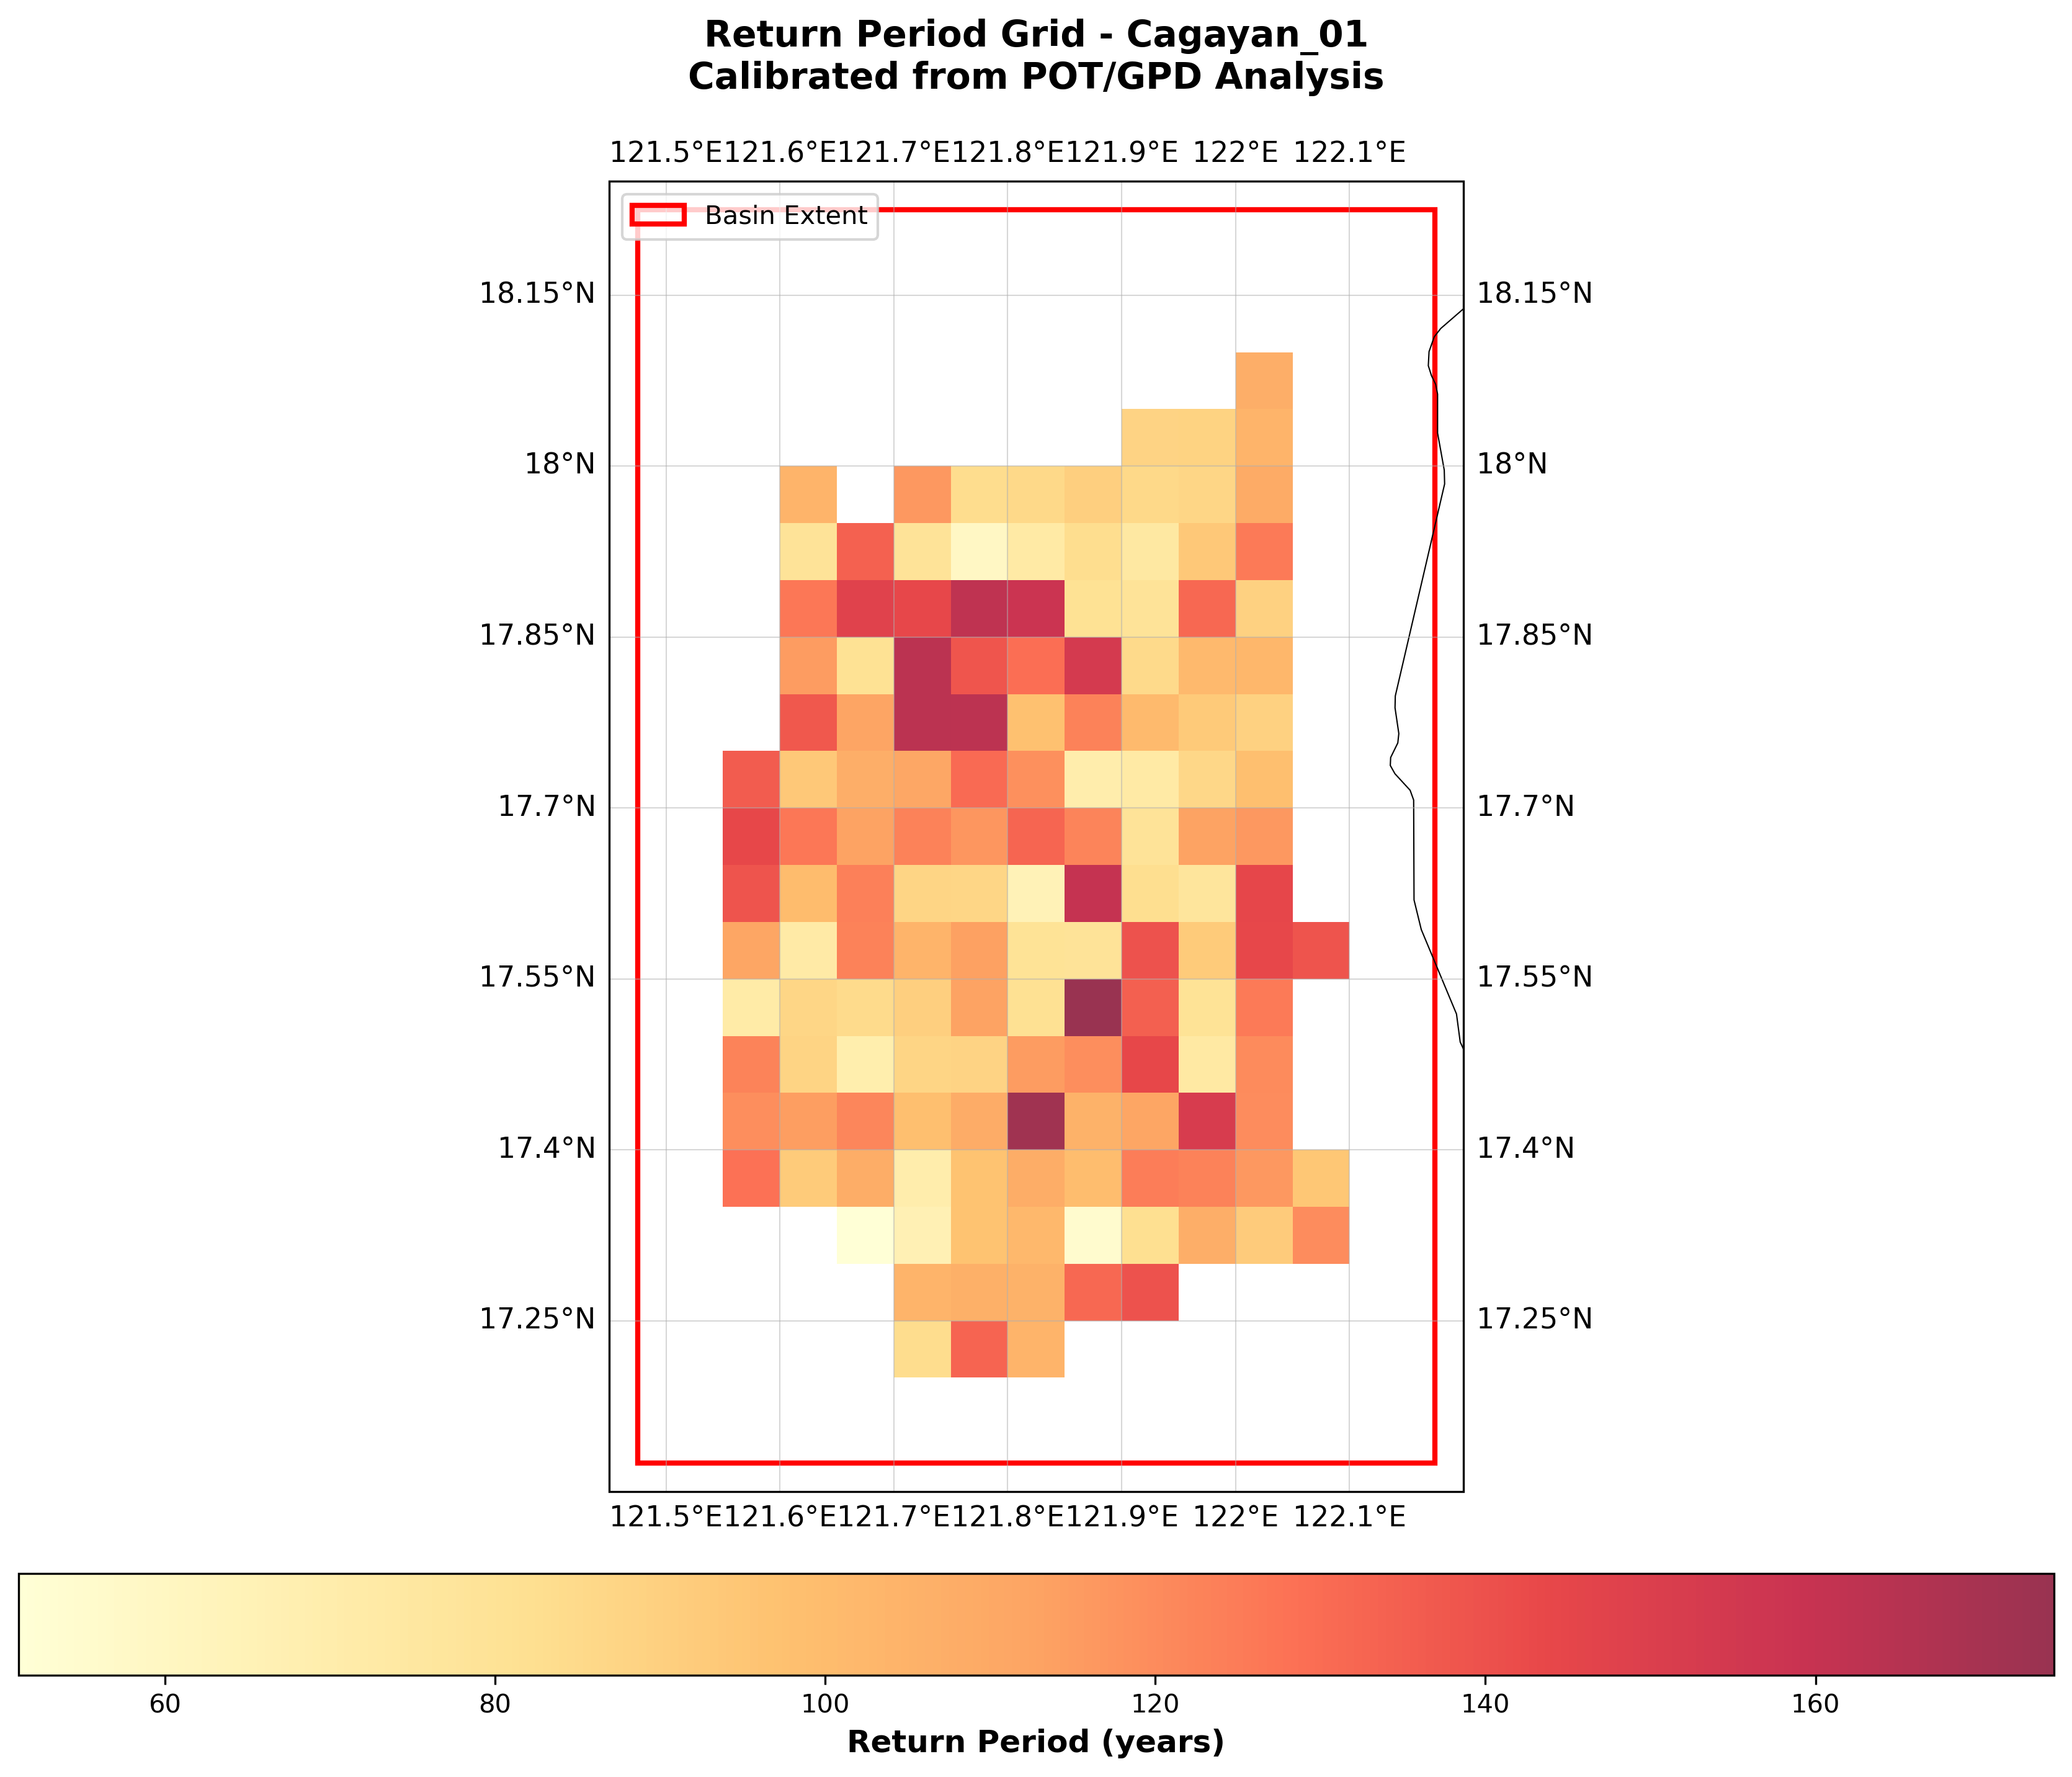

✓ Displayed: 01_return_period_map.png


Preview 2/5: 02_flood_depth_maps_by_rp.png



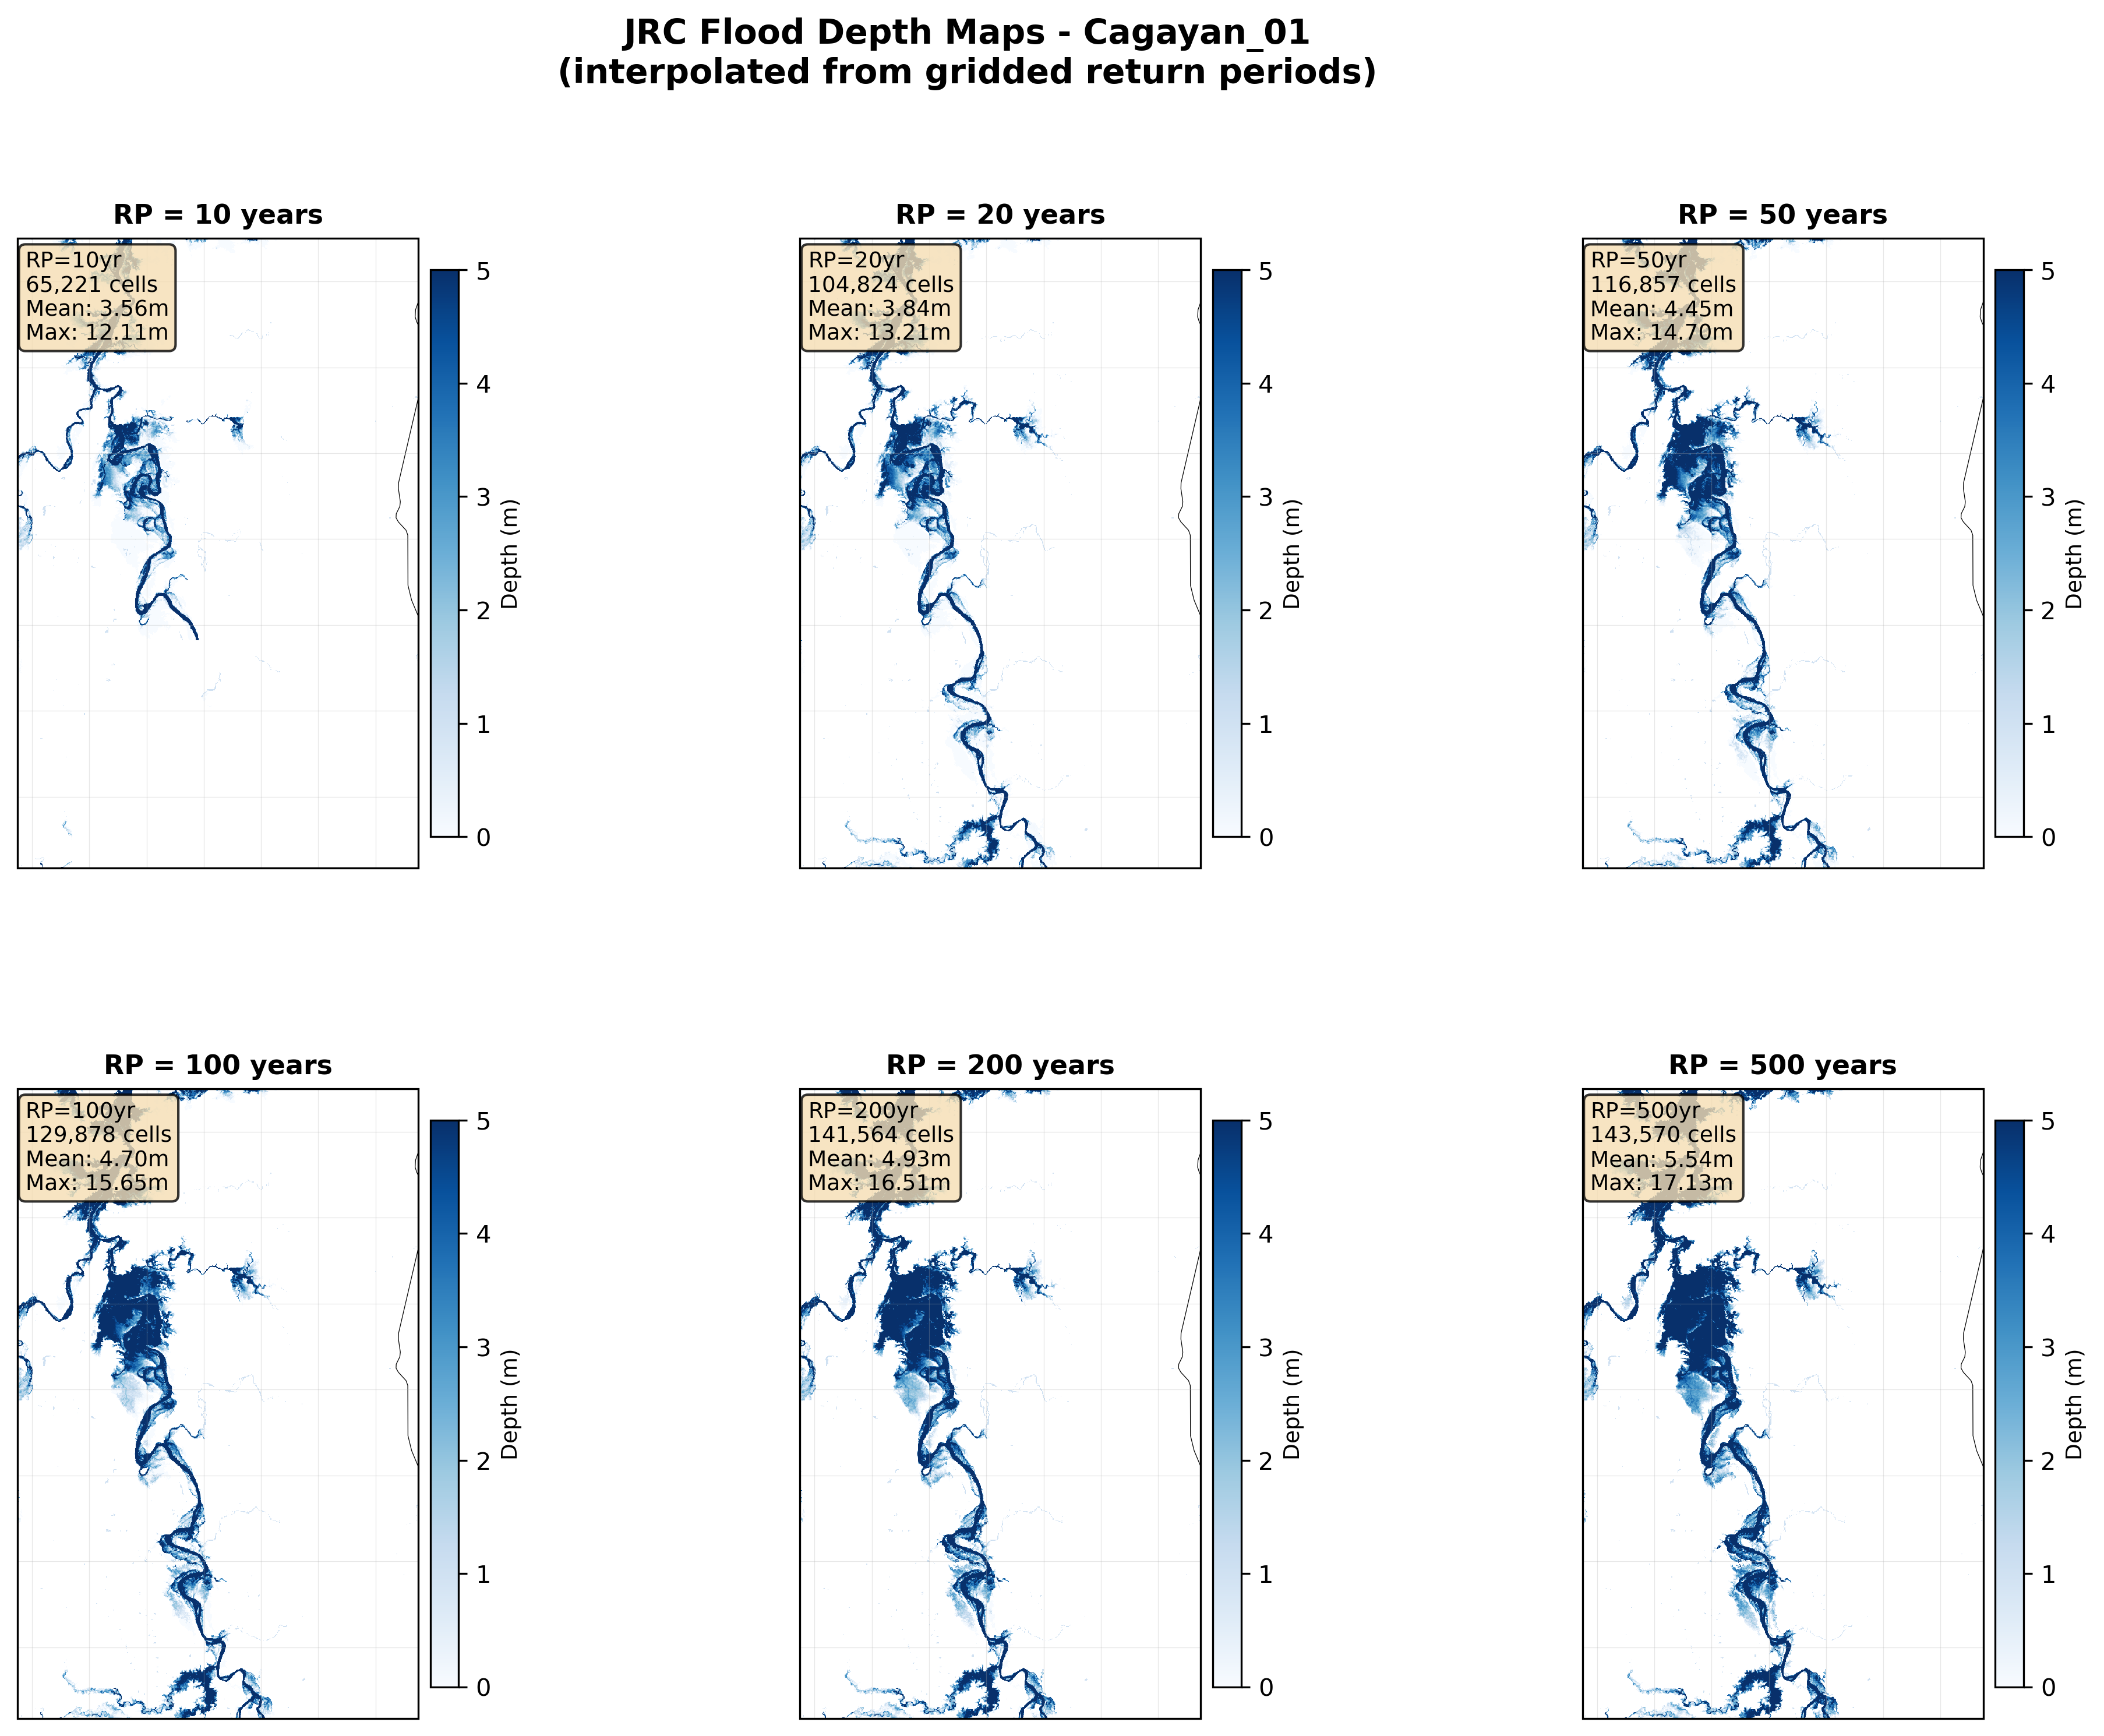

✓ Displayed: 02_flood_depth_maps_by_rp.png


Preview 3/5: 03_hazard_intensity_heatmap.png



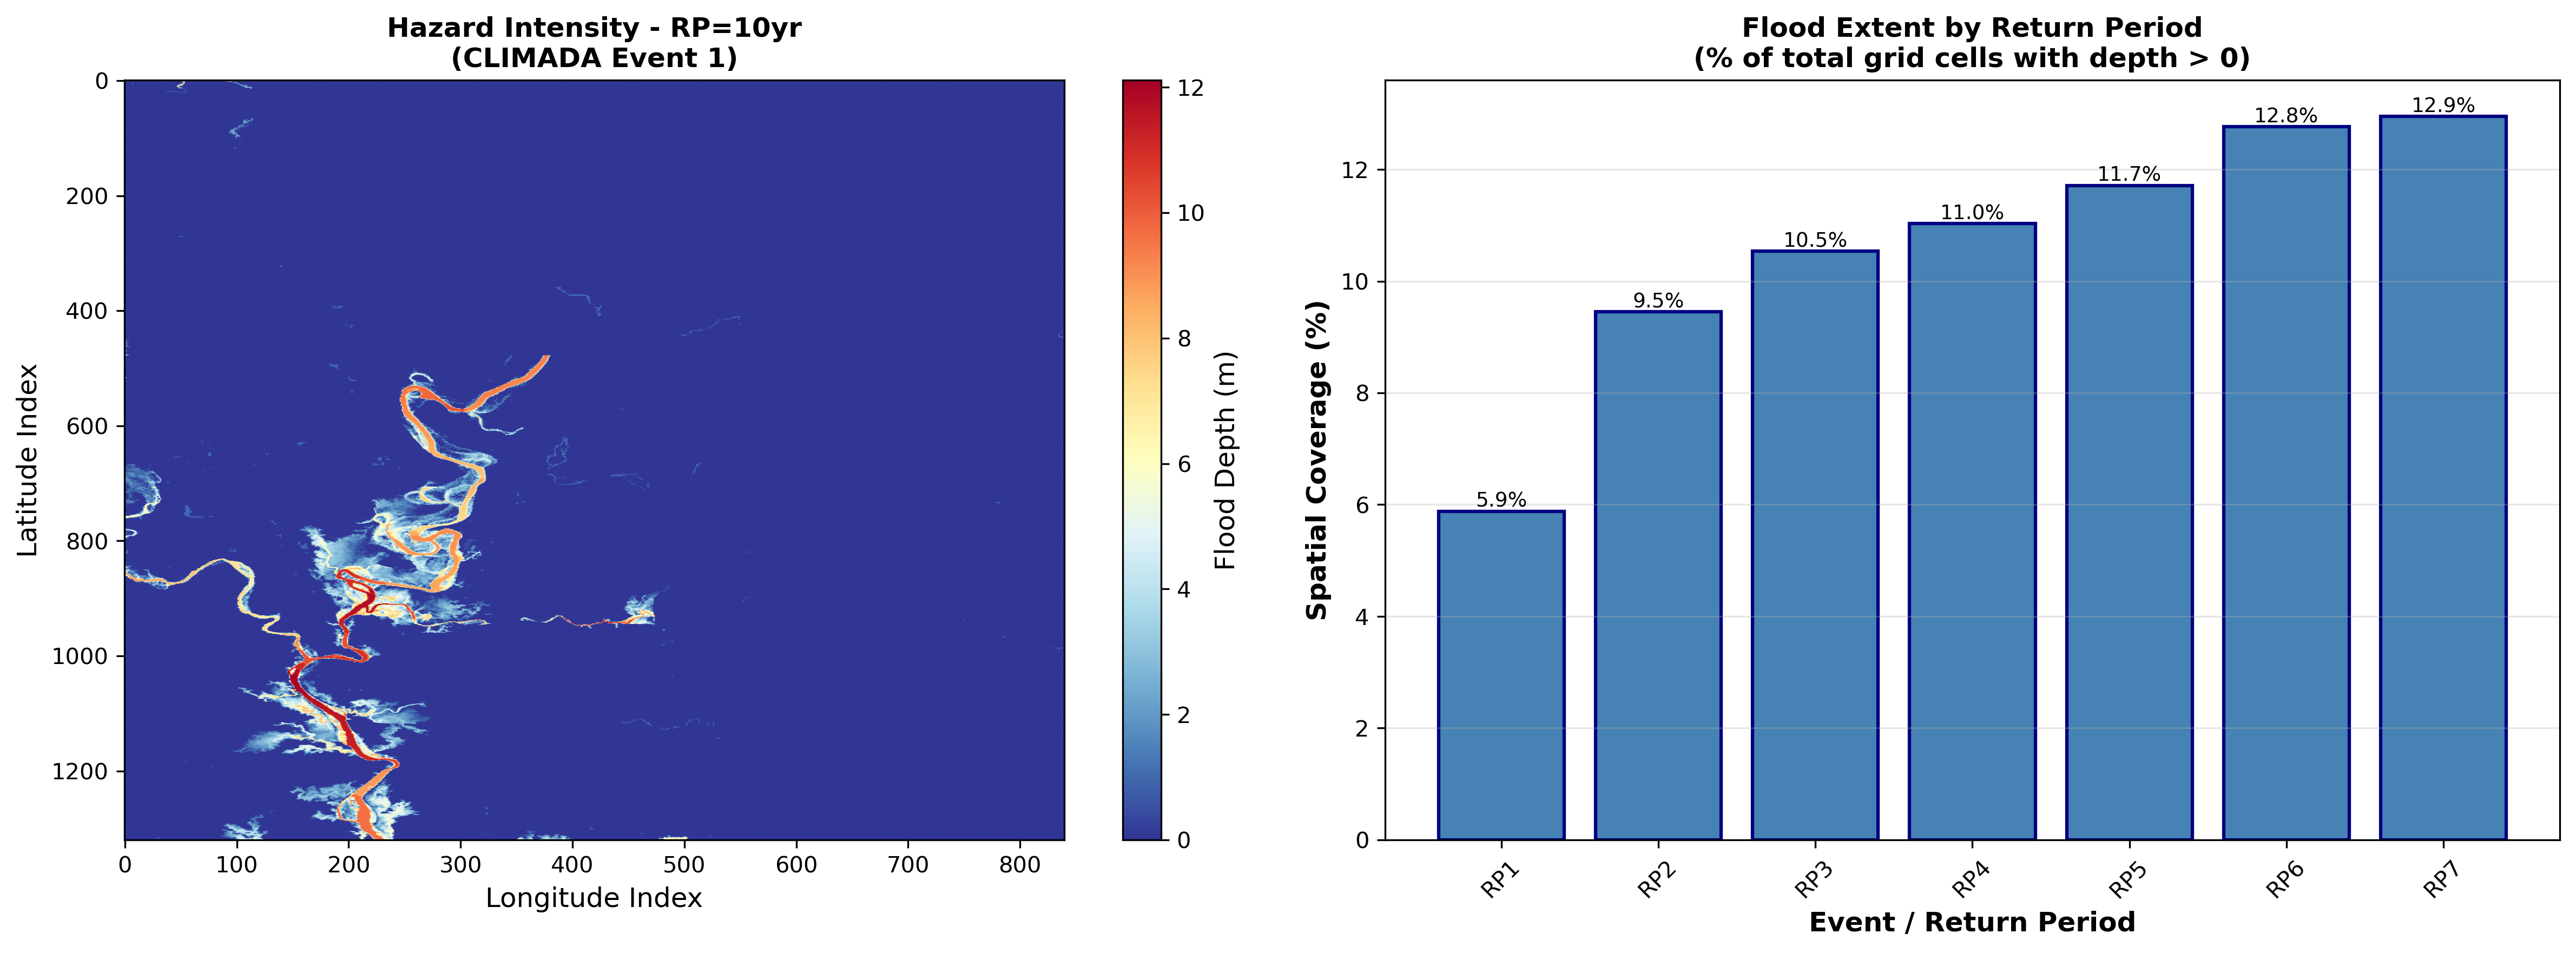

✓ Displayed: 03_hazard_intensity_heatmap.png


Preview 4/5: 04_exceedance_frequency_curves.png



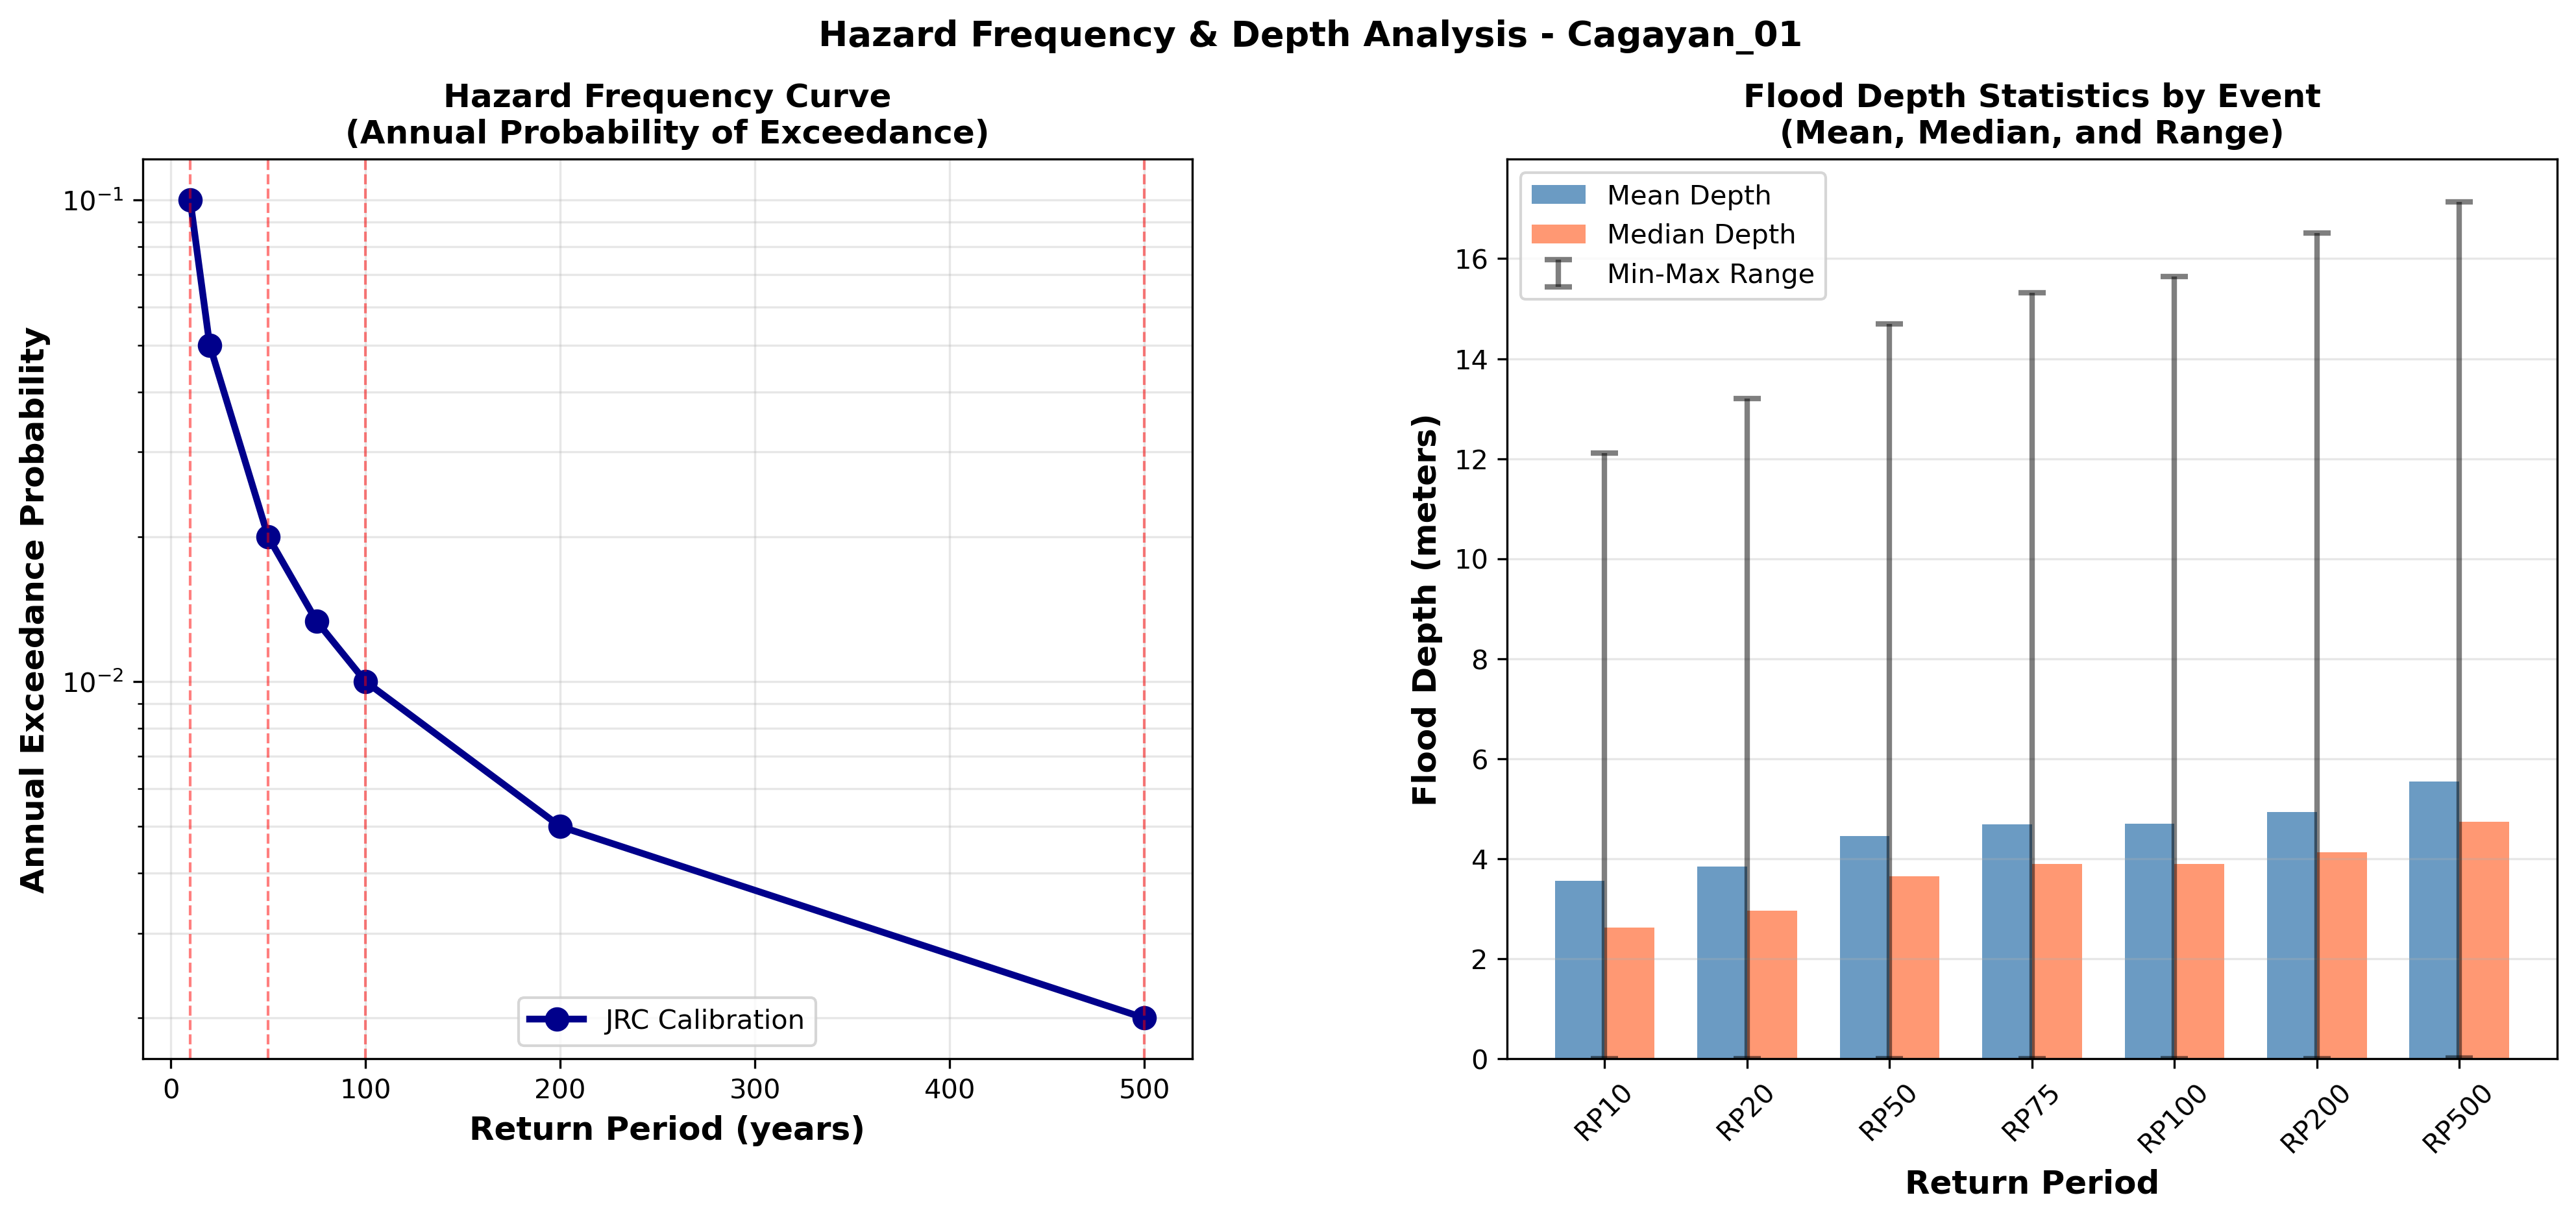

✓ Displayed: 04_exceedance_frequency_curves.png


Preview 5/5: 05_event_summary_dashboard.png



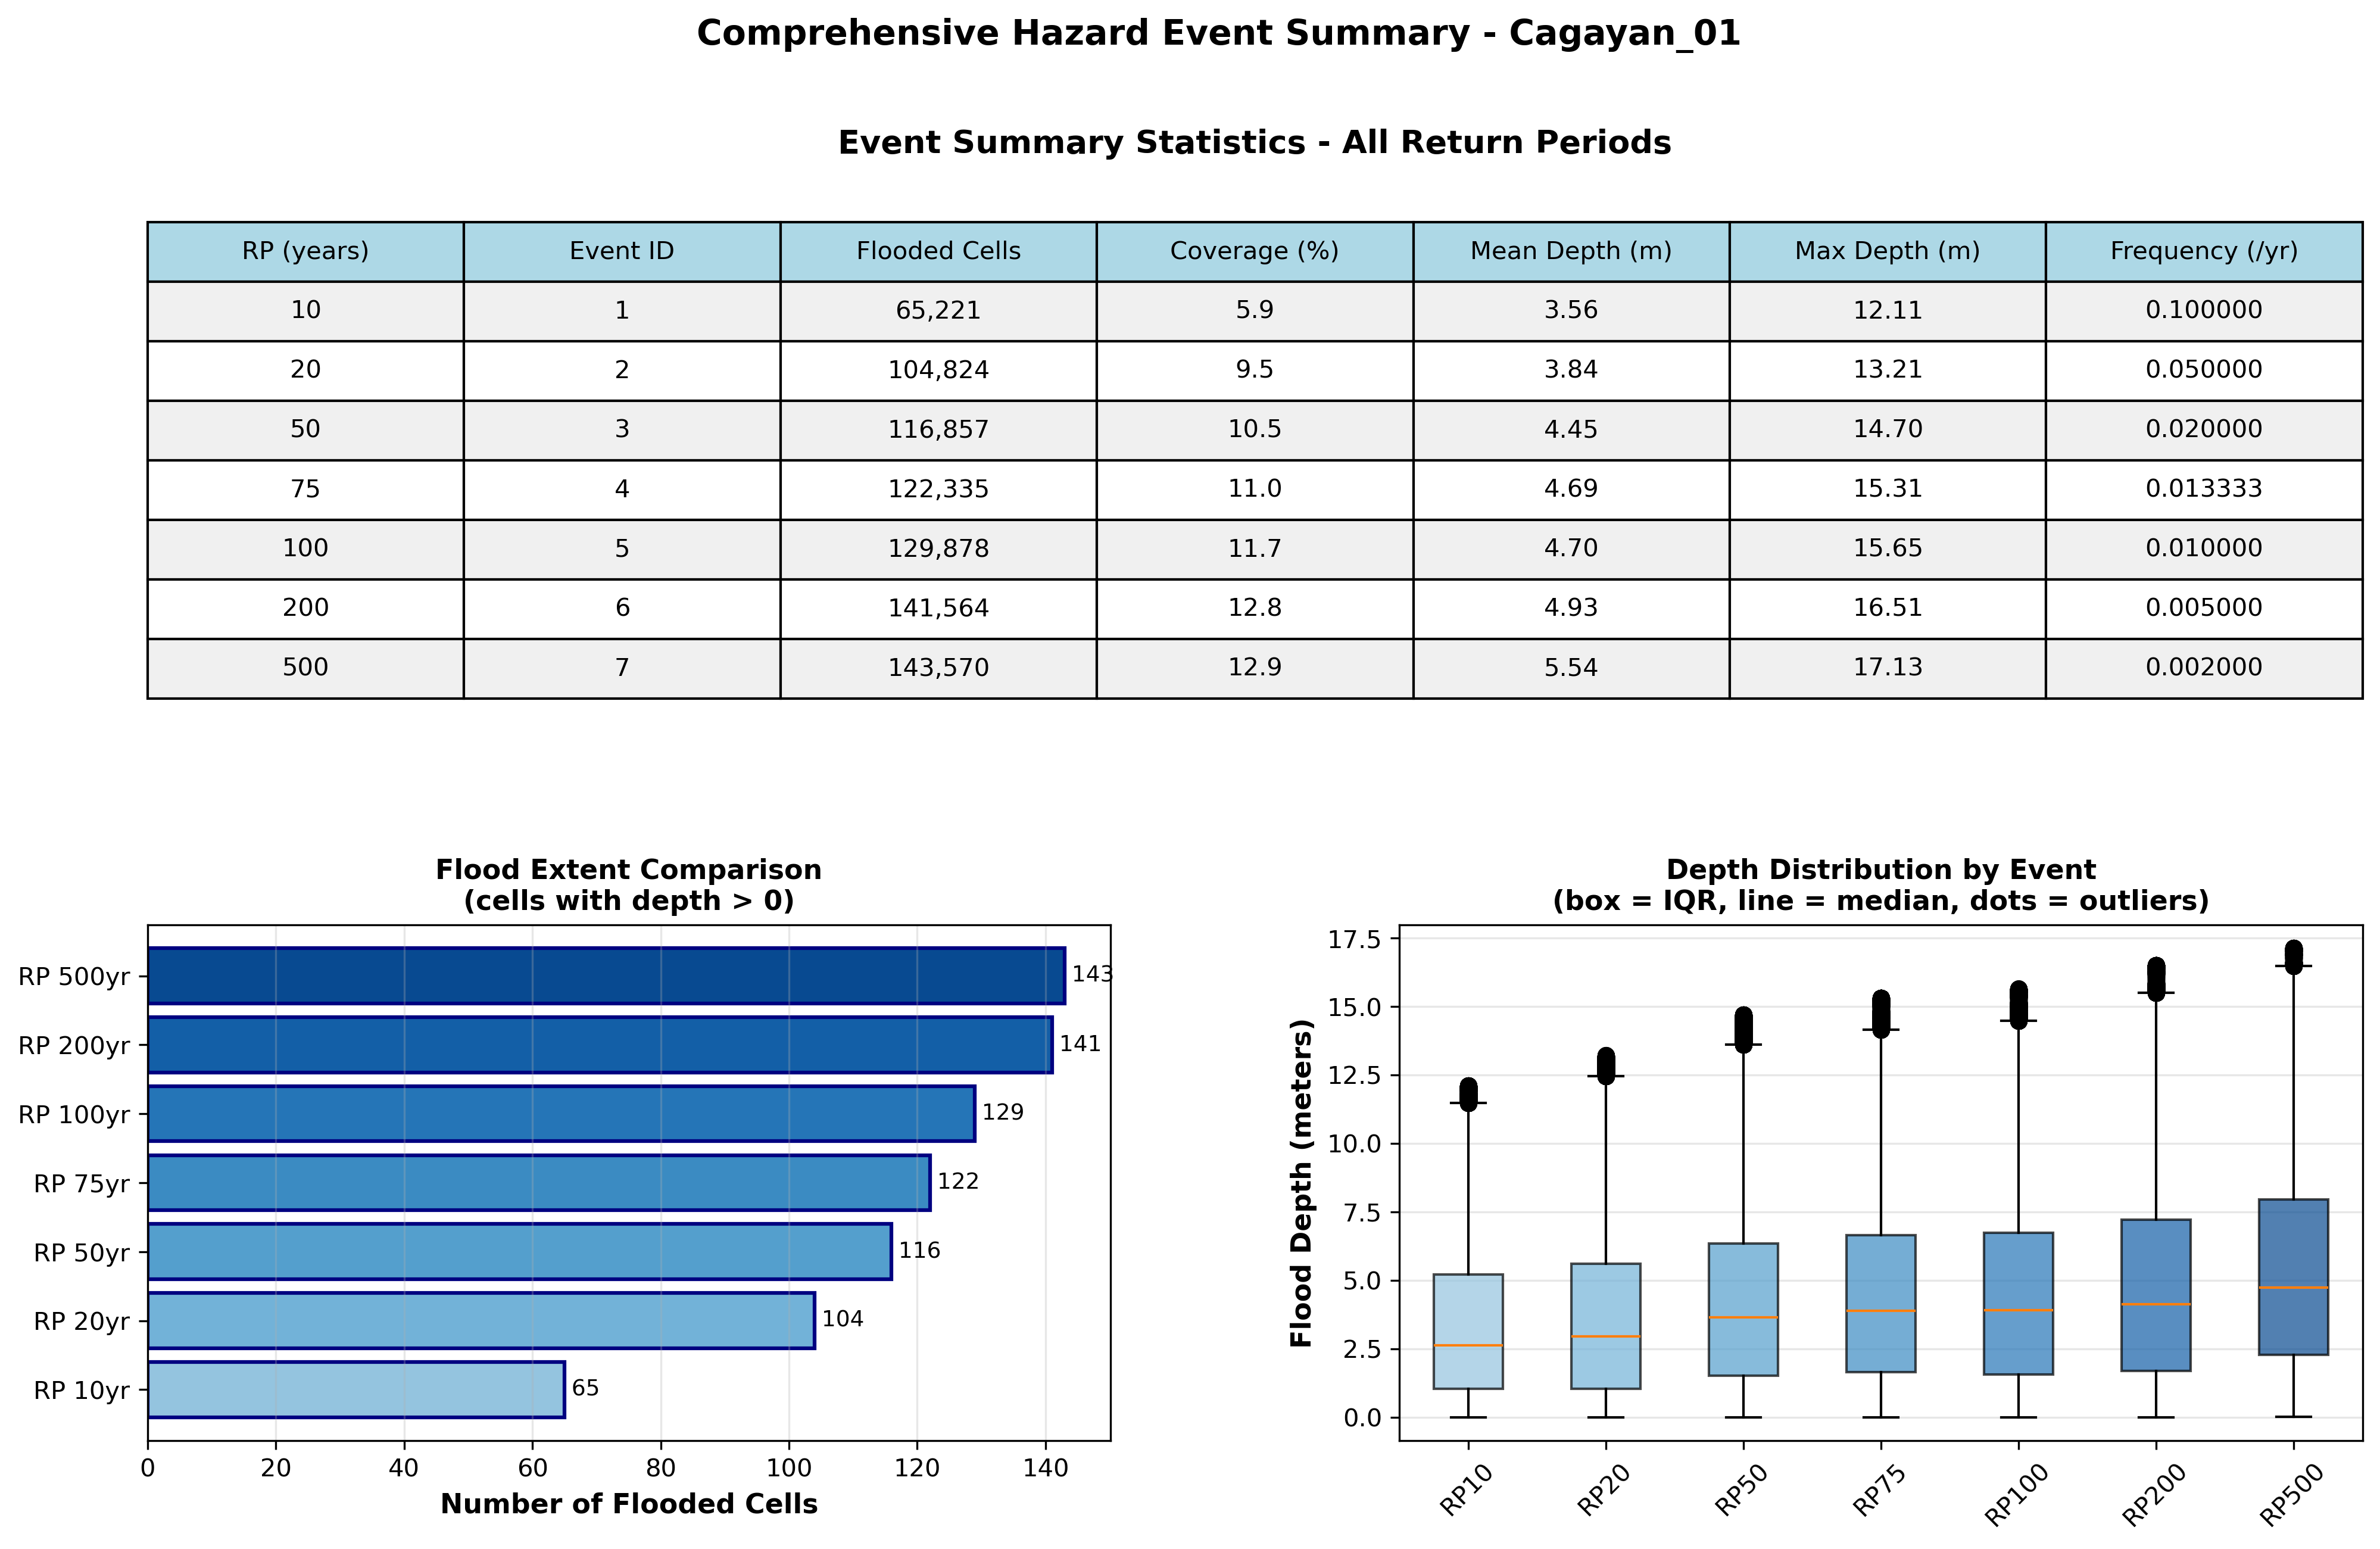

✓ Displayed: 05_event_summary_dashboard.png


FINAL VISUALIZATION SUMMARY

✓ Total visualizations generated: 6 files
✓ Total disk space: 3.5 MB
✓ All files saved in: c:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\climada_hazard\Cagayan_01\2026-01-19_calib-test\visualizations

💾 Files ready for presentation packages (PowerPoint, reports, email)
📊 High-resolution PNG (300 DPI) suitable for professional printing
🌐 Interactive HTML map available for stakeholder web distribution


In [18]:
# === Section 8.9: Display Previews (Inline) ===
print("\n📺 Displaying Visualization Previews...\n")

from IPython.display import Image as IPImage, display, HTML

# Display PNG previews
png_files = sorted(VIZ_OUTPUT.glob("*.png"))

for i, png_path in enumerate(png_files, 1):
    print(f"\n{'='*70}")
    print(f"Preview {i}/{len(png_files)}: {png_path.name}")
    print(f"{'='*70}\n")
    try:
        display(IPImage(filename=str(png_path), width=800))
        print(f"✓ Displayed: {png_path.name}\n")
    except Exception as e:
        print(f"⚠️  Could not display {png_path.name}: {e}\n")

# Summary stats for all visualizations
print("\n" + "="*70)
print("FINAL VISUALIZATION SUMMARY")
print("="*70)

total_size = sum(f.stat().st_size for f in VIZ_OUTPUT.glob("*"))
print(f"\n✓ Total visualizations generated: {len(viz_files)} files")
print(f"✓ Total disk space: {total_size / (1024**2):.1f} MB")
print(f"✓ All files saved in: {VIZ_OUTPUT}")
print(f"\n💾 Files ready for presentation packages (PowerPoint, reports, email)")
print(f"📊 High-resolution PNG (300 DPI) suitable for professional printing")
print(f"🌐 Interactive HTML map available for stakeholder web distribution")


## Section 7: Summary and Next Steps

## Section 6: Create CLIMADA Event-Based Hazard Objects